## Propeller performance analysis solving an uniform blade

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Constants and parameters
U_infty = 10.0      # Free stream velocity (m/s)
Omega = 100.0       # Angular velocity (rad/s)
R = 5.0             # Blade radius (m)
r_hub = 1.0         # Hub radius (m)
r = 2.5             # Radial position (m) (between hub and tip)
N = 3               # Number of blades
c = 0.5             # Chord length (m)
C_l = 1.0           # Lift coefficient (assumed)
C_d = 0.01          # Drag coefficient (assumed small)
C_x = C_d           # Drag coefficient
C_y = C_l           # Lift coefficient

# Non-dimensional parameters
mu_R = R / R        # mu at the tip (mu_R = 1)
mu = r / R          # Non-dimensional radial position

# Solidity
sigma = N * c / (2 * np.pi * r)

# Tip speed ratio
lambda_tsr = (Omega * R) / U_infty

# Convergence criteria
epsilon = 1e-6
max_iter = 1000

# Initial guesses
a0 = 0.3
a_prime0 = 0.01
phi0 = np.arctan2(U_infty, Omega * r)
f0 = 1.0


In [ ]:
# Initialize variables
a = a0
a_prime = a_prime0
phi = phi0
f = f0

# Arrays to store iteration history
a_history = [a]
a_prime_history = [a_prime]
phi_history = [phi]
f_history = [f]
iteration = [0]


In [ ]:
for n in range(1, max_iter + 1):
    # Store previous values
    a_prev = a
    a_prime_prev = a_prime
    phi_prev = phi
    f_prev = f

    # Step 1: Update phi
    numerator = U_infty * (1 + a_prev / f_prev)
    denominator = Omega * r * (1 - a_prime_prev / f_prev)
    phi = np.arctan2(numerator, denominator)

    # Step 2: Update f
    sin_phi = np.sin(phi)
    if np.abs(sin_phi) < 1e-6:
        sin_phi = np.sign(sin_phi) * 1e-6  # Avoid division by zero

    # Compute f_tip
    f_tip_exp = - (N / 2) * (R - r) / (r * sin_phi)
    f_tip_exp = np.clip(f_tip_exp, -100, 100)  # Avoid overflow
    f_tip = (2 / np.pi) * np.arccos(np.exp(f_tip_exp))
    f_tip = np.clip(f_tip, 1e-6, 1.0)  # Ensure f_tip is within [1e-6, 1]

    # Compute f_root
    f_root_exp = - (N / 2) * (r - r_hub) / (r * sin_phi)
    f_root_exp = np.clip(f_root_exp, -100, 100)  # Avoid overflow
    f_root = (2 / np.pi) * np.arccos(np.exp(f_root_exp))
    f_root = np.clip(f_root, 1e-6, 1.0)  # Ensure f_root is within [1e-6, 1]

    # Combine to get f
    f = f_tip * f_root
    f = np.clip(f, 1e-6, 1.0)  # Ensure f is within [1e-6, 1]

    # Step 3: Compute K
    sin_phi_sq = sin_phi ** 2
    mu_sq = mu ** 2
    numerator_K = 8 * lambda_tsr * mu_sq * a_prime_prev * (1 + a_prev) * sin_phi_sq
    denominator_K = sigma * C_y
    K = numerator_K / denominator_K if denominator_K != 0 else 0.0
    K = max(K, 0.0)  # Ensure K is non-negative

    # Step 4: Update a
    sqrt_K = np.sqrt(K)
    a = f * (sqrt_K - 1)
    a = np.clip(a, 0.0, 0.999)  # Ensure a is within [0, 0.999]

    # Step 5: Update a'
    numerator_ap = ((1 + a / f) ** 2) * sigma * C_y
    denominator_ap = 8 * lambda_tsr * mu_sq * (1 + a) * sin_phi_sq
    a_prime = numerator_ap / denominator_ap if denominator_ap != 0 else 0.0
    a_prime = max(a_prime, 0.0)  # Ensure a' is non-negative

    # Step 6: Convergence check
    delta_a = np.abs(a - a_prev)
    delta_a_prime = np.abs(a_prime - a_prime_prev)
    delta_phi = np.abs(phi - phi_prev)
    delta_f = np.abs(f - f_prev)

    # Store iteration data
    a_history.append(a)
    a_prime_history.append(a_prime)
    phi_history.append(phi)
    f_history.append(f)
    iteration.append(n)

    if delta_a < epsilon and delta_a_prime < epsilon and delta_phi < epsilon and delta_f < epsilon:
        print(f"Convergence achieved after {n} iterations.")
        break
else:
    print("Maximum iterations reached without convergence.")

# Convert iteration data to numpy arrays
a_history = np.array(a_history)
a_prime_history = np.array(a_prime_history)
phi_history = np.array(phi_history)
f_history = np.array(f_history)
iteration = np.array(iteration)


Convergence achieved after 33 iterations.


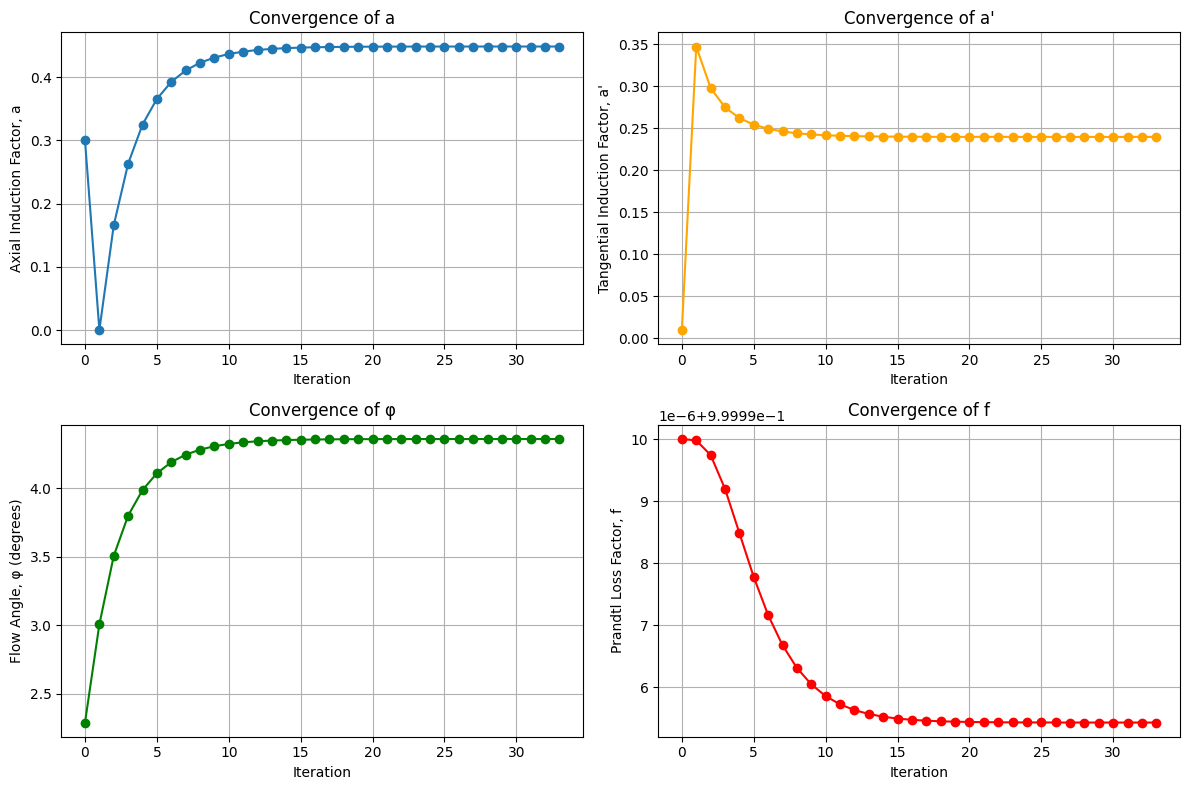

In [ ]:
# Plotting the convergence of variables
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(iteration, a_history, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Axial Induction Factor, a')
plt.title('Convergence of a')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(iteration, a_prime_history, marker='o', color='orange')
plt.xlabel('Iteration')
plt.ylabel('Tangential Induction Factor, a\'')
plt.title('Convergence of a\'')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(iteration, phi_history * 180 / np.pi, marker='o', color='green')
plt.xlabel('Iteration')
plt.ylabel('Flow Angle, φ (degrees)')
plt.title('Convergence of φ')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(iteration, f_history, marker='o', color='red')
plt.xlabel('Iteration')
plt.ylabel('Prandtl Loss Factor, f')
plt.title('Convergence of f')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
print(f"Final results after {n} iterations:")
print(f"Axial Induction Factor, a = {a}")
print(f"Tangential Induction Factor, a' = {a_prime}")
print(f"Flow Angle, φ = {phi * 180 / np.pi} degrees")
print(f"Prandtl Loss Factor, f = {f}")


Final results after 33 iterations:
Axial Induction Factor, a = 0.44849572108755015
Tangential Induction Factor, a' = 0.23961521624439341
Flow Angle, φ = 4.357416512269744 degrees
Prandtl Loss Factor, f = 0.999995433433724


##Propeller performance analysis solving multiple annuli

In [ ]:
r_R,c_D,P_D,beta_deg,t_M_c,f_M_c
0.2,0.32,1.105,0,0.2055,0.01429
0.3,0.3635,1.102,0,0.1553,0.02318
0.4,0.4048,1.098,0,0.1180,0.02303
0.5,0.4392,1.093,0,0.09016,0.02182
0.6,0.4610,1.088,0,0.06960,0.02072
0.7,0.4622,1.084,0,0.05418,0.02003
0.8,0.4347,1.081,0,0.04206,0.01967
0.9,0.3613,1.079,0,0.03321,0.01817
0.95,0.2775,1.077,0,0.03228,0.01631
1.0,0.0,1.075,0,0.03160,0.01175

In [ ]:
# Load propeller geometry data from CSV file
data = pd.read_csv('propeller_data.csv')
data = data.dropna()
# Extract data
r_R = data['r_R'].values
c_D = data['c_D'].values
P_D = data['P_D'].values
t_M_c = data['t_M_c'].values
f_M_c = data['f_M_c'].values

In [ ]:
import pandas as pd
from io import StringIO

# Define the data as a string
data_str = """r_R,c_D,P_D,beta_deg,t_M_c,f_M_c
0.2,0.32,1.105,0,0.2055,0.01429
0.3,0.3635,1.102,0,0.1553,0.02318
0.4,0.4048,1.098,0,0.1180,0.02303
0.5,0.4392,1.093,0,0.09016,0.02182
0.6,0.4610,1.088,0,0.06960,0.02072
0.7,0.4622,1.084,0,0.05418,0.02003
0.8,0.4347,1.081,0,0.04206,0.01967
0.9,0.3613,1.079,0,0.03321,0.01817
0.95,0.2775,1.077,0,0.03228,0.01631
1.0,0.0,1.075,0,0.03160,0.01175"""

# Read the data into a pandas DataFrame
data = pd.read_csv(StringIO(data_str))

# Now you can extract the data as before
r_R = data['r_R'].values
c_D = data['c_D'].values
P_D = data['P_D'].values
beta_deg = data['beta_deg'].values
t_M_c = data['t_M_c'].values
f_M_c = data['f_M_c'].values
# Convert beta from degrees to radians
beta = np.radians(beta_deg)

In [ ]:
# Constants
rho = 1025  # Seawater density (kg/m^3)

# Propeller Parameters
D = 0.305  # Diameter (m)
R = D / 2  # Radius (m)
r_hub = 0.2 * R  # Hub radius (m)
N = 3  # Number of blades
n = 15  # Rotational speed (rev/s)
Omega = 2 * np.pi * n  # Angular velocity (rad/s)

# Operating Conditions
V_infty = 3.0  # Free-stream velocity (m/s)

In [ ]:
# Number of annuli
num_annuli = len(r_R)

# Radial positions
r = r_R * R
dr = np.diff(r)
dr = np.append(dr, dr[-1])  # Assume last dr is same as second last

# Chord lengths
c = c_D * D

# Compute pitch at each radial position
P = P_D * D

# Compute blade angle (pitch angle) at each annulus
beta = np.arctan(P / (np.pi * D * r_R))  # Blade angle in radians

# Initialize arrays for results
a = np.zeros(num_annuli)
a_prime = np.zeros(num_annuli)
phi = np.zeros(num_annuli)
f = np.ones(num_annuli)

In [ ]:
# Assumed airfoil characteristics
C_l_alpha = 2 * np.pi  # Lift curve slope (per radian)
alpha_0 = 0  # Zero-lift angle of attack (radians)
C_d0 = 0.008  # Profile drag coefficient at zero lift
k = 0.01  # Quadratic drag coefficient factor

# Angle of attack for each annulus will be computed during iteration

In [ ]:
def picard_iteration(V_infty, Omega, r, c, beta, sigma, N, epsilon=1e-6, max_iter=10000):
    num_annuli = len(r)
    a = 0.1 * np.ones(num_annuli)
    a_prime = 0.01 * np.ones(num_annuli)
    phi = np.arctan2(V_infty, Omega * r)
    f = np.ones(num_annuli)
    relaxation_factor = 0.4  # Under-relaxation factor

    for i in range(num_annuli):
        for n_iter in range(1, max_iter + 1):
            a_prev = a[i]
            a_prime_prev = a_prime[i]
            phi_prev = phi[i]
            f_prev = f[i]

            # Step 1: Update phi (corrected)
            numerator = V_infty * (1 - a_prev)
            denominator = Omega * r[i] * (1 + a_prime_prev)
            phi[i] = np.arctan2(numerator, denominator)

            # Ensure phi is between 0 and pi/2
            phi[i] = np.clip(phi[i], 1e-3, np.pi / 2 - 1e-3)

            # Step 2: Compute sin_phi
            sin_phi = np.sin(phi[i])
            sin_phi = max(sin_phi, 1e-3)  # Prevent very small sin_phi

            # Step 3: Compute angle of attack
            alpha = phi[i] - beta[i]
            alpha_deg = np.degrees(alpha)

            # Limit angle of attack
            alpha_deg = np.clip(alpha_deg, -10, 10)
            alpha = np.radians(alpha_deg)

            # Step 4: Estimate C_l and C_d
            C_l = C_l_alpha * alpha  # Linear lift curve
            C_d = C_d0 + k * C_l ** 2  # Quadratic drag polar

            # Step 5: Compute f (Prandtl's loss factor)
            f_tip_exp = - (N / 2) * (R - r[i]) / (r[i] * sin_phi)
            f_root_exp = - (N / 2) * (r[i] - r_hub) / (r[i] * sin_phi)

            # Ensure exponents are negative or zero
            f_tip_exp = np.clip(f_tip_exp, None, 0)
            f_root_exp = np.clip(f_root_exp, None, 0)

            exp_f_tip = np.exp(f_tip_exp)
            exp_f_tip = np.clip(exp_f_tip, 0.0, 1.0)
            f_tip = (2 / np.pi) * np.arccos(exp_f_tip)
            f_tip = np.clip(f_tip, 1e-3, 1.0)

            exp_f_root = np.exp(f_root_exp)
            exp_f_root = np.clip(exp_f_root, 0.0, 1.0)
            f_root = (2 / np.pi) * np.arccos(exp_f_root)
            f_root = np.clip(f_root, 1e-3, 1.0)

            f[i] = f_tip * f_root
            f[i] = np.clip(f[i], 1e-3, 1.0)

            # Step 6: Compute sigma
            sigma_i = (N * c[i]) / (2 * np.pi * r[i])

            # Step 7: Update a and a' (corrected)
            K = (C_l * sigma_i) / (4 * sin_phi ** 2)
            a_new = K / (1 + K)
            a_new = np.clip(a_new, 0.0, 0.95)

            K_prime = (C_l * sigma_i) / (4 * sin_phi * np.cos(phi[i]))
            a_prime_new = K_prime / (1 + K_prime)
            a_prime_new = np.clip(a_prime_new, 0.0, 0.5)

            # Under-relaxation
            a_unmodified = a_prev + relaxation_factor * (a_new - a_prev)
            a_prime_unmodified = a_prime_prev + relaxation_factor * (a_prime_new - a_prime_prev)

            # Apply Prandtl's loss factor
            a[i] = a_unmodified / f[i]
            a_prime[i] = a_prime_unmodified / f[i]

            # Constrain a and a' within physical limits
            a[i] = np.clip(a[i], 0.0, 0.95)
            a_prime[i] = np.clip(a_prime[i], 0.0, 0.5)

            # Convergence check
            delta_a = np.abs(a[i] - a_prev)
            delta_a_prime = np.abs(a_prime[i] - a_prime_prev)
            delta_phi = np.abs(phi[i] - phi_prev)
            delta_f = np.abs(f[i] - f_prev)

            if delta_a < epsilon and delta_a_prime < epsilon and delta_phi < epsilon and delta_f < epsilon:
                break

        else:
            print(f"Annulus at r/R = {r_R[i]:.2f}: Maximum iterations reached without convergence.")

    # Add the return statement to output the results
    return a, a_prime, phi, f


In [ ]:
# Compute solidity sigma for each annulus
sigma = (N * c) / (2 * np.pi * r)

# Run the Picard iteration
a, a_prime, phi, f = picard_iteration(V_infty, Omega, r, c, beta, sigma, N)

# Compute relative wind speed at each annulus
W = np.sqrt((V_infty * (1 + a / f)) ** 2 + (Omega * r * (1 - a_prime / f)) ** 2)

# Recalculate angle of attack and lift/drag coefficients
alpha = phi - beta
C_l = C_l_alpha * alpha
C_d = C_d0 + k * C_l ** 2

# Compute elemental thrust and torque
delta_T = 0.5 * rho * W ** 2 * N * c * (C_l * np.cos(phi) - C_d * np.sin(phi)) * dr
delta_Q = 0.5 * rho * W ** 2 * N * c * (C_l * np.sin(phi) + C_d * np.cos(phi)) * r * dr

# Total thrust and torque
T = np.sum(delta_T)
Q = np.sum(delta_Q)

# Compute non-dimensional coefficients
D = 2 * R  # Propeller diameter
K_T = T / (rho * n ** 2 * D ** 4)
K_Q = Q / (rho * n ** 2 * D ** 5)
J = V_infty / (n * D)
eta = (J * K_T) / (2 * np.pi * K_Q)

NameError: name 'picard_iteration' is not defined

In [ ]:
print(f"Total Thrust, T = {T:.2f} N")
print(f"Total Torque, Q = {Q:.2f} Nm")
print(f"Thrust Coefficient, K_T = {K_T:.5f}")
print(f"Torque Coefficient, K_Q = {K_Q:.5f}")
print(f"Advance Coefficient, J = {J:.3f}")
print(f"Propeller Efficiency, η = {eta:.3f}")

Total Thrust, T = -149657962.89 N
Total Torque, Q = 138849.76 Nm
Thrust Coefficient, K_T = -74988.40021
Torque Coefficient, K_Q = 228.10750
Advance Coefficient, J = 0.656
Propeller Efficiency, η = -34.309


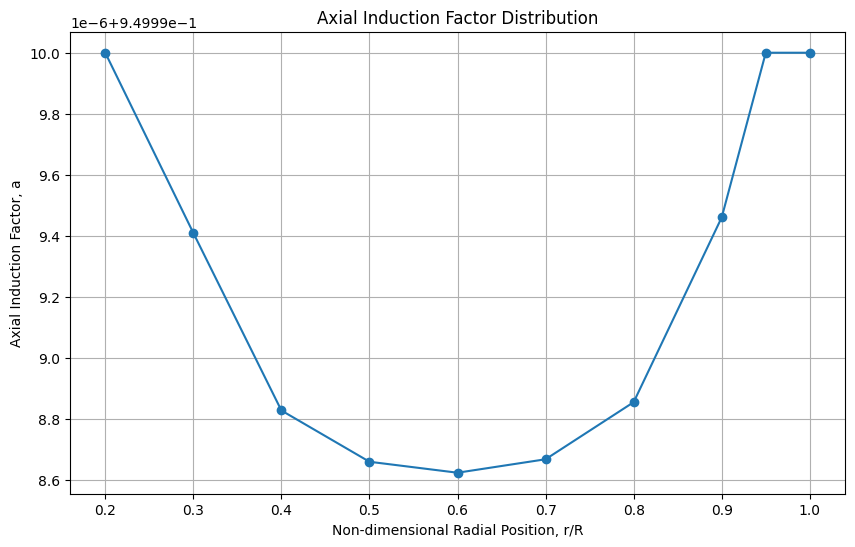

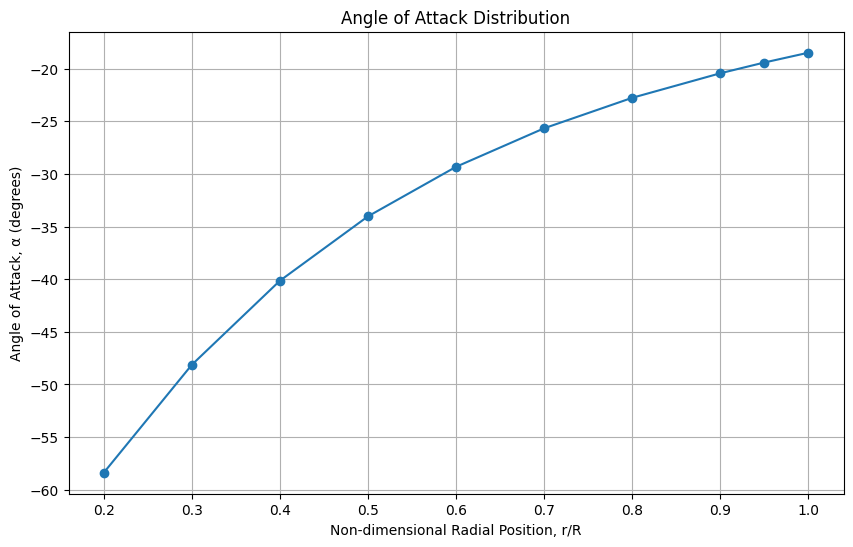

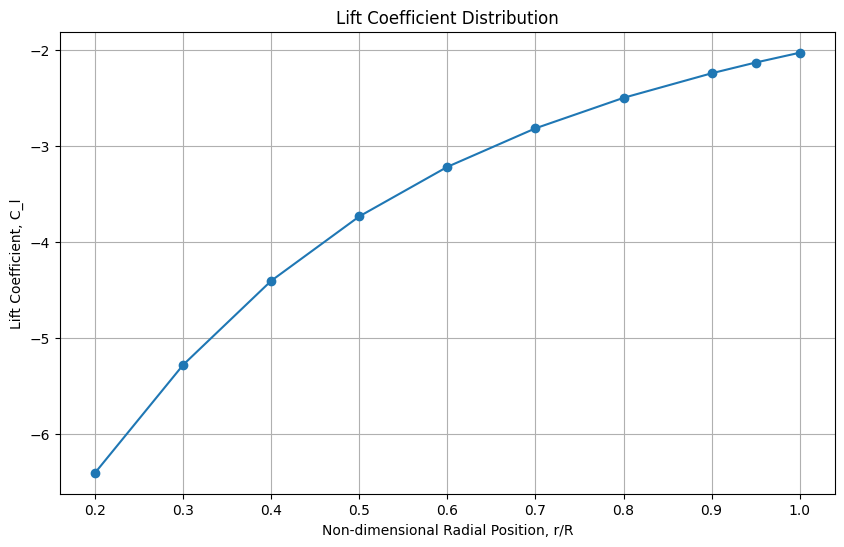

In [ ]:
# Plot axial induction factor along the blade
plt.figure(figsize=(10, 6))
plt.plot(r_R, a, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Axial Induction Factor, a')
plt.title('Axial Induction Factor Distribution')
plt.grid(True)
plt.show()

# Plot angle of attack distribution
plt.figure(figsize=(10, 6))
plt.plot(r_R, np.degrees(alpha), marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Angle of Attack, α (degrees)')
plt.title('Angle of Attack Distribution')
plt.grid(True)
plt.show()

# Plot lift coefficient distribution
plt.figure(figsize=(10, 6))
plt.plot(r_R, C_l, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Lift Coefficient, C_l')
plt.title('Lift Coefficient Distribution')
plt.grid(True)
plt.show()


In [ ]:
# Constants
rho = 1.225  # Air density (kg/m^3)

# Propeller Parameters
U_infty = 10.0      # Free-stream velocity (m/s)
Omega = 100.0       # Angular velocity (rad/s)
R = 5.0             # Blade radius (m)
r_hub = 1.0         # Hub radius (m)
N = 3               # Number of blades

In [ ]:
# Lift and Drag Coefficient Distributions (example)
C_l = 1.0 * np.ones_like(r)
C_d = 0.01 * np.ones_like(r)

## Begin from the middle annulus and, if converged, spread to tip and root

 Idea to improve convergence by starting from the middle section and then propagating the solution outward to both the root and tip of the blade. The approach will involve initializing the axial and tangential induction factors for the middle annulus, using these as initial guesses, and solving outward from this point.

In [ ]:
def picard_iteration_improved(V_infty, Omega, r, c, beta, sigma, N, epsilon=1e-6, max_iter=10000):
    num_annuli = len(r)

    # Initialize induction factors
    a = 0.1 * np.ones(num_annuli)
    a_prime = 0.01 * np.ones(num_annuli)
    phi = np.arctan2(V_infty, Omega * r)
    f = np.ones(num_annuli)

    # Middle annulus index
    mid_index = num_annuli // 2
    relaxation_factor = 0.4  # Under-relaxation factor

    # Helper function to solve for one annulus
    def solve_annulus(i, a_prev, a_prime_prev, phi_prev):
        nonlocal a, a_prime, phi, f

        for n_iter in range(1, max_iter + 1):
            # Step 1: Update phi
            numerator = V_infty * (1 - a_prev)
            denominator = Omega * r[i] * (1 + a_prime_prev)
            phi[i] = np.arctan2(numerator, denominator)

            # Ensure phi is within reasonable limits
            phi[i] = np.clip(phi[i], 1e-3, np.pi / 2 - 1e-3)

            # Step 2: Compute sin_phi
            sin_phi = np.sin(phi[i])
            sin_phi = max(sin_phi, 1e-3)  # Avoid division by zero

            # Step 3: Angle of attack and coefficients
            alpha = phi[i] - beta[i]
            alpha_deg = np.clip(np.degrees(alpha), -10, 10)
            alpha = np.radians(alpha_deg)

            C_l = C_l_alpha * alpha
            C_d = C_d0 + k * C_l ** 2

            # Step 4: Compute Prandtl's loss factor f
            f_tip_exp = - (N / 2) * (R - r[i]) / (r[i] * sin_phi)
            f_root_exp = - (N / 2) * (r[i] - r_hub) / (r[i] * sin_phi)

            f_tip_exp = np.clip(f_tip_exp, None, 0)
            f_root_exp = np.clip(f_root_exp, None, 0)

            f_tip = (2 / np.pi) * np.arccos(np.clip(np.exp(f_tip_exp), 0.0, 1.0))
            f_root = (2 / np.pi) * np.arccos(np.clip(np.exp(f_root_exp), 0.0, 1.0))

            f[i] = f_tip * f_root
            f[i] = np.clip(f[i], 1e-3, 1.0)

            # Step 5: Compute sigma
            sigma_i = (N * c[i]) / (2 * np.pi * r[i])

            # Step 6: Update a and a_prime
            K = (C_l * sigma_i) / (4 * sin_phi ** 2)
            a_new = np.clip(K / (1 + K), 0.0, 0.95)

            K_prime = (C_l * sigma_i) / (4 * sin_phi * np.cos(phi[i]))
            a_prime_new = np.clip(K_prime / (1 + K_prime), 0.0, 0.5)

            # Apply under-relaxation
            a[i] = a_prev + relaxation_factor * (a_new - a_prev)
            a_prime[i] = a_prime_prev + relaxation_factor * (a_prime_new - a_prime_prev)

            # Apply Prandtl's loss factor
            a[i] = a[i] / f[i]
            a_prime[i] = a_prime[i] / f[i]

            # Constrain a and a' within physical limits
            a[i] = np.clip(a[i], 0.0, 0.95)
            a_prime[i] = np.clip(a_prime[i], 0.0, 0.5)

            # Convergence check
            if np.abs(a[i] - a_prev) < epsilon and np.abs(a_prime[i] - a_prime_prev) < epsilon:
                break
        return a[i], a_prime[i], phi[i], f[i]

    # Solve for the middle annulus first
    a[mid_index], a_prime[mid_index], phi[mid_index], f[mid_index] = solve_annulus(
        mid_index, a[mid_index], a_prime[mid_index], phi[mid_index])

    # Propagate solutions toward the root
    for i in range(mid_index - 1, -1, -1):
        a[i], a_prime[i], phi[i], f[i] = solve_annulus(i, a[i + 1], a_prime[i + 1], phi[i + 1])

    # Propagate solutions toward the tip
    for i in range(mid_index + 1, num_annuli):
        a[i], a_prime[i], phi[i], f[i] = solve_annulus(i, a[i - 1], a_prime[i - 1], phi[i - 1])

    return a, a_prime, phi, f


In [ ]:
print(f"Total Thrust, T = {T:.2f} N")
print(f"Total Torque, Q = {Q:.2f} Nm")
print(f"Thrust Coefficient, K_T = {K_T:.5f}")
print(f"Torque Coefficient, K_Q = {K_Q:.5f}")
print(f"Advance Coefficient, J = {J:.3f}")
print(f"Propeller Efficiency, η = {eta:.3f}")

Total Thrust, T = -149657962.89 N
Total Torque, Q = 138849.76 Nm
Thrust Coefficient, K_T = -74988.40021
Torque Coefficient, K_Q = 228.10750
Advance Coefficient, J = 0.656
Propeller Efficiency, η = -34.309


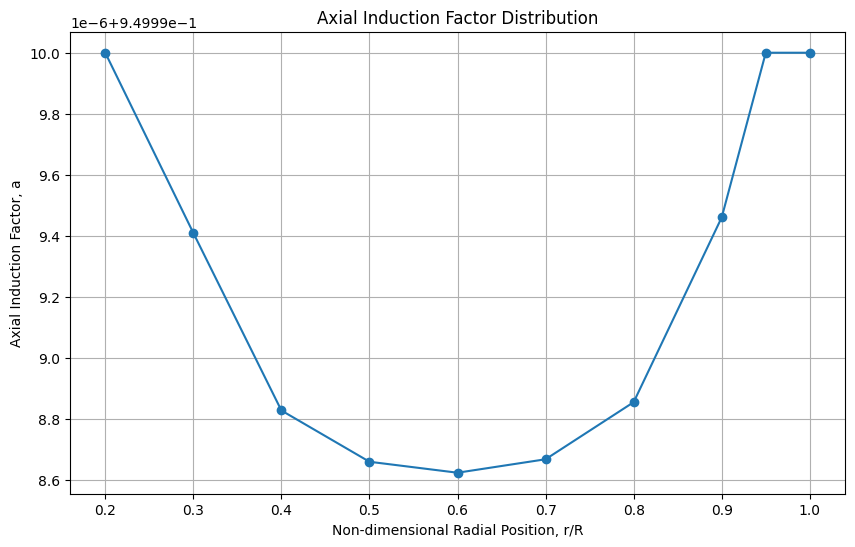

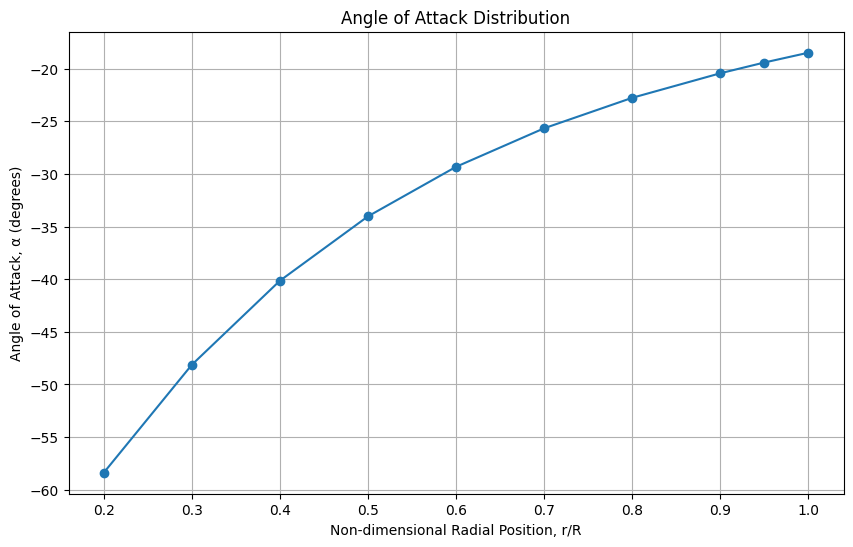

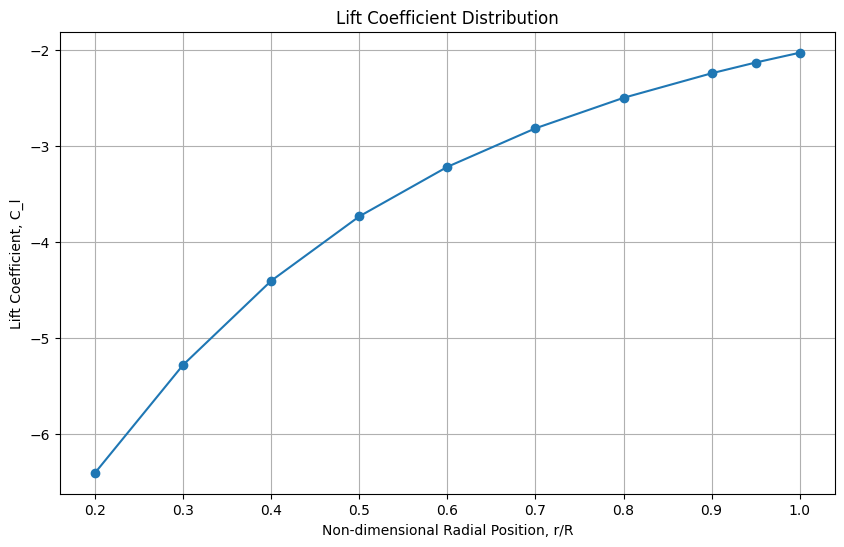

In [ ]:
# Plot axial induction factor along the blade
plt.figure(figsize=(10, 6))
plt.plot(r_R, a, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Axial Induction Factor, a')
plt.title('Axial Induction Factor Distribution')
plt.grid(True)
plt.show()

# Plot angle of attack distribution
plt.figure(figsize=(10, 6))
plt.plot(r_R, np.degrees(alpha), marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Angle of Attack, α (degrees)')
plt.title('Angle of Attack Distribution')
plt.grid(True)
plt.show()

# Plot lift coefficient distribution
plt.figure(figsize=(10, 6))
plt.plot(r_R, C_l, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Lift Coefficient, C_l')
plt.title('Lift Coefficient Distribution')
plt.grid(True)
plt.show()


## Unified cell

0 0.95
Iteration 0, Annulus 0, Phi: 0.749131, a: 0.341627, a': 0.293058, f': 0.950000
0 0.95
Iteration 1, Annulus 0, Phi: 0.488435, a: 0.425691, a': 0.404623, f': 0.950000
0 0.95
Iteration 2, Annulus 0, Phi: 0.403321, a: 0.493466, a': 0.492313, f': 0.950000
0 0.95
Iteration 3, Annulus 0, Phi: 0.340448, a: 0.550714, a': 0.564243, f': 0.950000
0 0.95
Iteration 4, Annulus 0, Phi: 0.291234, a: 0.600114, a': 0.624474, f': 0.950000
0 0.95
Iteration 5, Annulus 0, Phi: 0.251468, a: 0.643253, a': 0.675522, f': 0.950000
0 0.95
Iteration 6, Annulus 0, Phi: 0.218656, a: 0.681209, a': 0.719126, f': 0.950000
0 0.95
Iteration 7, Annulus 0, Phi: 0.191167, a: 0.714773, a': 0.756575, f': 0.950000
0 0.95
Iteration 8, Annulus 0, Phi: 0.167868, a: 0.744559, a': 0.788863, f': 0.950000
0 0.95
Iteration 9, Annulus 0, Phi: 0.147938, a: 0.771061, a': 0.816780, f': 0.950000
0 0.95
Iteration 10, Annulus 0, Phi: 0.130762, a: 0.794690, a': 0.840972, f': 0.950000
0 0.95
Iteration 11, Annulus 0, Phi: 0.115868, a: 0.8

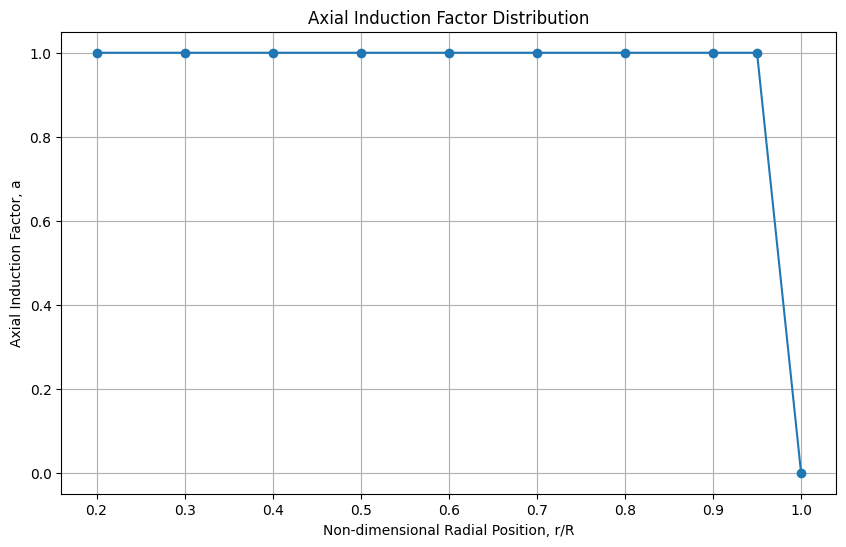

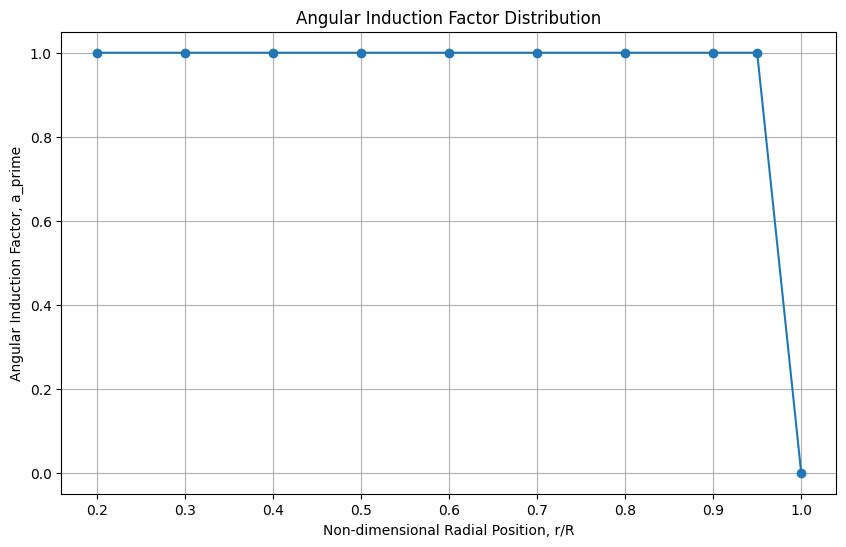

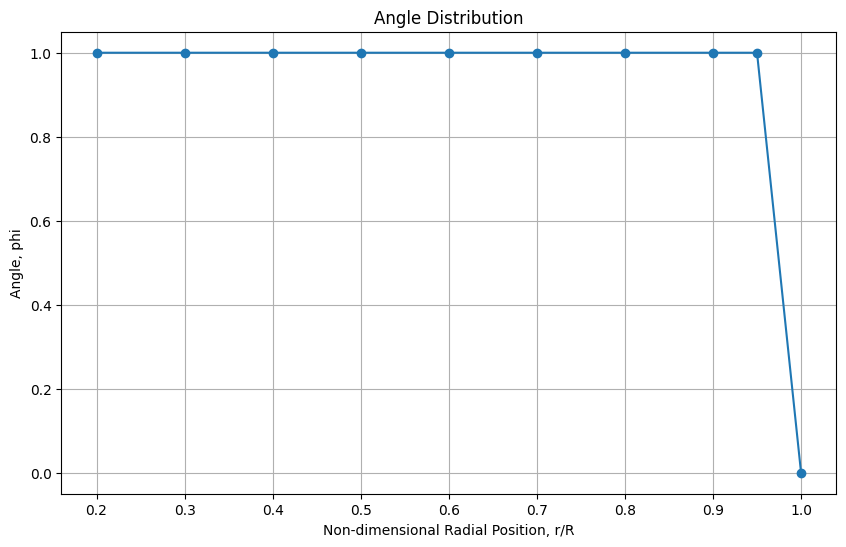

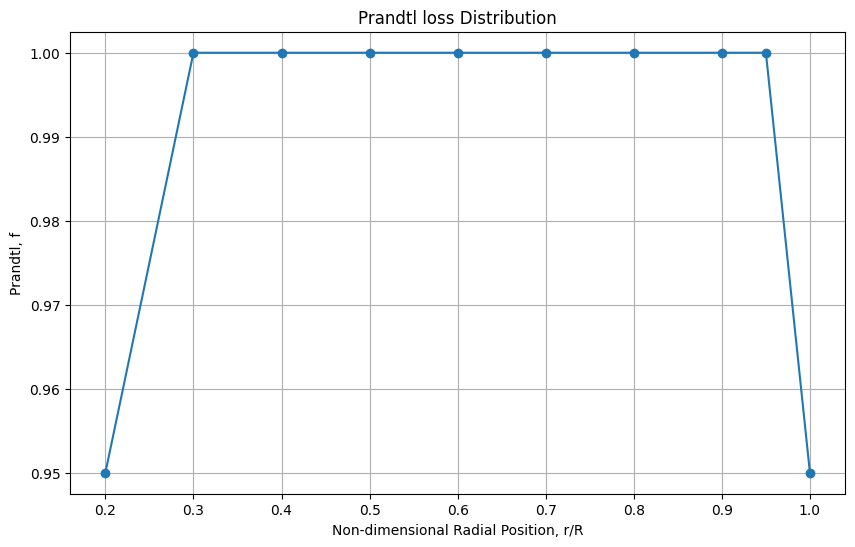

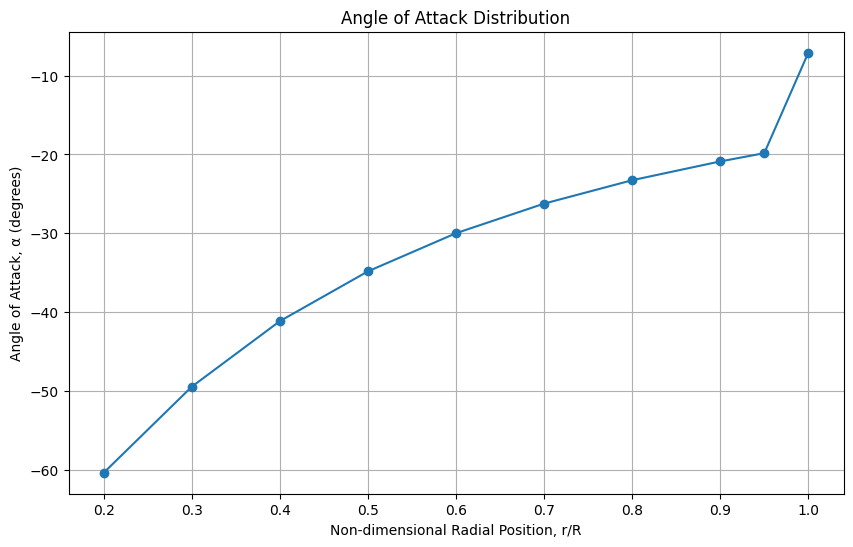

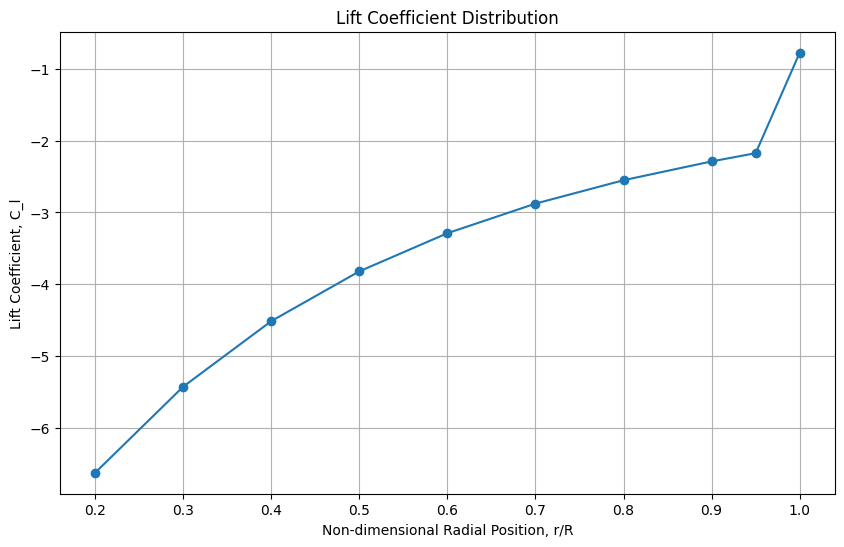

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

# Define the data as a string
data_str = """r_R,c_D,P_D,beta_deg,t_M_c,f_M_c
0.2,0.32,1.105,0,0.2055,0.01429
0.3,0.3635,1.102,0,0.1553,0.02318
0.4,0.4048,1.098,0,0.1180,0.02303
0.5,0.4392,1.093,0,0.09016,0.02182
0.6,0.4610,1.088,0,0.06960,0.02072
0.7,0.4622,1.084,0,0.05418,0.02003
0.8,0.4347,1.081,0,0.04206,0.01967
0.9,0.3613,1.079,0,0.03321,0.01817
0.95,0.2775,1.077,0,0.03228,0.01631
1.0,0.0,1.075,0,0.03160,0.01175"""

# Read the data into a pandas DataFrame
data = pd.read_csv(StringIO(data_str))

# Constants
rho = 1025  # Seawater density (kg/m^3)
D = 0.305  # Diameter (m)
R = D / 2  # Radius (m)
r_hub = 0.2 * R  # Hub radius (m)
N = 3  # Number of blades
n = 15  # Rotational speed (rev/s)
Omega = 2 * np.pi * n  # Angular velocity (rad/s)
V_infty = 3.0  # Free-stream velocity (m/s)

# Extract data
r_R = data['r_R'].values
c_D = data['c_D'].values
P_D = data['P_D'].values
beta_deg = data['beta_deg'].values
t_M_c = data['t_M_c'].values
f_M_c = data['f_M_c'].values

# Convert beta from degrees to radians
beta = np.radians(beta_deg)

# Compute derived quantities
num_annuli = len(r_R)
r = r_R * R
dr = np.diff(r)
dr = np.append(dr, dr[-1])  # Assume last dr is same as second last
c = c_D * D
P = P_D * D
beta = np.arctan(P / (np.pi * D * r_R))  # Blade angle in radians

# Assumed airfoil characteristics
C_l_alpha = 2 * np.pi  # Lift curve slope (per radian)
alpha_0 = 0  # Zero-lift angle of attack (radians)
C_d0 = 0.008  # Profile drag coefficient at zero lift
k = 0.01  # Quadratic drag coefficient factor

# Initialize arrays for iterative solver
a = np.zeros(num_annuli)
a_prime = np.zeros(num_annuli)
phi = np.zeros(num_annuli)
f = np.ones(num_annuli)

def picard_iteration_improved(V_infty, Omega, r, c, beta, N, epsilon=1e-6, max_iter=1000):
    num_annuli = len(r)
    rho = 1025  # Seawater density (kg/m^3)
    C_l_alpha = 2 * np.pi  # Lift curve slope (per radian)
    C_d0 = 0.008  # Profile drag coefficient at zero lift
    k = 0.01  # Quadratic drag coefficient factor
    R = r[-1]  # Propeller maximum radius
    r_hub = r[0]  # Hub radius
    dr = np.diff(r, append=r[-1] - r[-2])  # Ensure consistent spacing for last element

    # Initialize variables
    a = 0.1 * np.ones(num_annuli)
    a_prime = 0.01 * np.ones(num_annuli)
    phi = np.arctan2(V_infty, Omega * r)
    f = np.ones(num_annuli)
    alpha = np.zeros(num_annuli)  # Initialize alpha for each annulus

    relaxation_factor = 0.1  # Under-relaxation factor

    # Initialize arrays for delta_T and delta_Q
    delta_T = np.zeros(num_annuli)
    delta_Q = np.zeros(num_annuli)

    for i in range(num_annuli):
        a_prev = a[i]
        a_prime_prev = a_prime[i]
        for n_iter in range(max_iter):
            numerator = V_infty * (1 - a_prev)
            denominator = Omega * r[i] * (1 + a_prime_prev)
            if abs(denominator) > 1e-6:
                phi[i] = np.arctan2(numerator, denominator)
            else:
                phi[i] += 1e-6  # adjust slightly instead of setting to a fixed small value

            # Avoid division by zero in phi
            if np.abs(np.sin(phi[i])) < 1e-6:
                phi[i] = phi[i] + 1e-6

            # Compute relative wind speed
            W = np.sqrt(numerator**2 + denominator**2)

            # Recalculate angle of attack and lift/drag coefficients
            alpha[i] = phi[i] - beta[i]
            C_l = C_l_alpha * alpha[i]
            C_d = C_d0 + k * C_l**2

            # Compute elemental thrust and torque
            delta_T[i] = 0.5 * rho * W**2 * N * c[i] * (C_l * np.cos(phi[i]) - C_d * np.sin(phi[i])) * dr[i]
            delta_Q[i] = 0.5 * rho * W**2 * N * c[i] * (C_l * np.sin(phi[i]) + C_d * np.cos(phi[i])) * r[i] * dr[i]

            # Compute Prandtl's loss factor
            f_tip_exp = - (N / 2) * (R - r[i]) / (r[i] * np.sin(phi[i]))
            f_root_exp = - (N / 2) * (r[i] - r_hub) / (r[i] * np.sin(phi[i]))

            f_tip = (2 / np.pi) * np.arccos(np.clip(np.exp(f_tip_exp), 0.0, 1.0))
            f_root = (2 / np.pi) * np.arccos(np.clip(np.exp(f_root_exp), 0.0, 1.0))

            f[i] = f_tip * f_root
            f[i] = np.clip(f[i], 0.95, 1.0)

            print(i,f[i])

            # Compute sigma
            sigma_i = (N * c[i]) / (2 * np.pi * r[i])

            # Update a and a_prime
            K = (C_l * sigma_i) / (4 * f[i] * np.sin(phi[i])**2)
            a_new = K / (1 + K)
            K_prime = (C_l * sigma_i) / (4 * f[i] * np.sin(phi[i]) * np.cos(phi[i]))
            a_prime_new = K_prime / (1 + K_prime)

            # Apply under-relaxation
            a[i] = a_prev + relaxation_factor * (a_new - a_prev)
            a_prime[i] = a_prime_prev + relaxation_factor * (a_prime_new - a_prime_prev)

            # Constrain a and a'
            a[i] = np.clip(a[i], 0.0, 1.5)
            a_prime[i] = np.clip(a_prime[i], 0.0, 1.5)

            # Log output for debugging
            print(f"Iteration {n_iter}, Annulus {i}, Phi: {phi[i]:.6f}, a: {a[i]:.6f}, a': {a_prime[i]:.6f}, f': {f[i]:.6f}")

            # Check convergence
            if np.abs(a[i] - a_prev) < epsilon and np.abs(a_prime[i] - a_prime_prev) < epsilon:
                break

            # Update previous values
            a_prev = a[i]
            a_prime_prev = a_prime[i]

    # Total thrust and torque
    T = np.sum(delta_T)
    Q = np.sum(delta_Q)

    # Non-dimensional coefficients and efficiency
    D = 2 * R
    K_T = T / (rho * n**2 * D**4)
    K_Q = Q / (rho * n**2 * D**5)
    J = V_infty / (n * D)
    eta = (J * K_T) / (2 * np.pi * K_Q)

    return a, a_prime, phi, f, T, Q, K_T, K_Q, J, eta, alpha

# Implement Picard iteration
a, a_prime, phi, f, T, Q, K_T, K_Q, J, eta, alpha = picard_iteration_improved(V_infty, Omega, r, c, beta, N)

print(f"Total Thrust, T = {T:.2f} N")
print(f"Total Torque, Q = {Q:.2f} Nm")
print(f"Thrust Coefficient, K_T = {K_T:.5f}")
print(f"Torque Coefficient, K_Q = {K_Q:.5f}")
print(f"Advance Coefficient, J = {J:.3f}")
print(f"Propeller Efficiency, η = {eta:.3f}")

# Plot axial induction factor along the blade
plt.figure(figsize=(10, 6))
plt.plot(r_R, a, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Axial Induction Factor, a')
plt.title('Axial Induction Factor Distribution')
plt.grid(True)
plt.show()

# Plot angular induction factor along the blade
plt.figure(figsize=(10, 6))
plt.plot(r_R, a_prime, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Angular Induction Factor, a_prime')
plt.title('Angular Induction Factor Distribution')
plt.grid(True)
plt.show()

# Plot phi angle along the blade
plt.figure(figsize=(10, 6))
plt.plot(r_R, a, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Angle, phi')
plt.title('Angle Distribution')
plt.grid(True)
plt.show()

# Plot phi angle along the blade
plt.figure(figsize=(10, 6))
plt.plot(r_R, f, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Prandtl, f')
plt.title('Prandtl loss Distribution')
plt.grid(True)
plt.show()

# Plot angle of attack distribution
plt.figure(figsize=(10, 6))
plt.plot(r_R, np.degrees(alpha), marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Angle of Attack, α (degrees)')
plt.title('Angle of Attack Distribution')
plt.grid(True)
plt.show()

# Plot lift coefficient distribution
C_l = C_l_alpha * alpha  # Recalculate lift coefficient distribution
plt.figure(figsize=(10, 6))
plt.plot(r_R, C_l, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Lift Coefficient, C_l')
plt.title('Lift Coefficient Distribution')
plt.grid(True)
plt.show()


Iteration 0, Annulus 5, Phi: 0.259706, a: 0.329469, a': 0.147690, f': 0.950000
Iteration 1, Annulus 5, Phi: 0.172480, a: 0.472899, a': 0.199646, f': 0.983743
Iteration 2, Annulus 5, Phi: 0.130274, a: 0.546770, a': 0.200196, f': 0.995319
Iteration 3, Annulus 5, Phi: 0.112130, a: 0.567579, a': 0.177669, f': 0.997920
Iteration 4, Annulus 5, Phi: 0.109053, a: 0.572613, a': 0.159167, f': 0.998234
Iteration 5, Annulus 5, Phi: 0.109501, a: 0.576822, a': 0.148817, f': 0.998190
Iteration 6, Annulus 5, Phi: 0.109400, a: 0.579083, a': 0.142439, f': 0.998200
Iteration 7, Annulus 5, Phi: 0.109423, a: 0.580499, a': 0.138650, f': 0.998198
Iteration 8, Annulus 5, Phi: 0.109417, a: 0.581335, a': 0.136368, f': 0.998198
Iteration 9, Annulus 5, Phi: 0.109419, a: 0.581840, a': 0.135001, f': 0.998198
Iteration 10, Annulus 5, Phi: 0.109418, a: 0.582142, a': 0.134180, f': 0.998198
Iteration 11, Annulus 5, Phi: 0.109419, a: 0.582324, a': 0.133687, f': 0.998198
Iteration 12, Annulus 5, Phi: 0.109419, a: 0.58243

<ipython-input-23-1d610e0a2e8c>:118: RuntimeWarning: invalid value encountered in scalar divide
  eta = (J * K_T) / (2 * np.pi * K_Q)


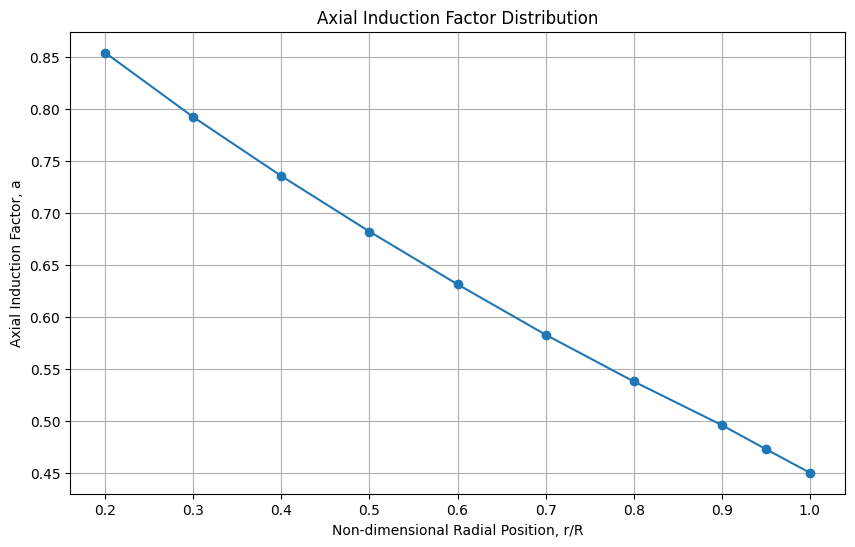

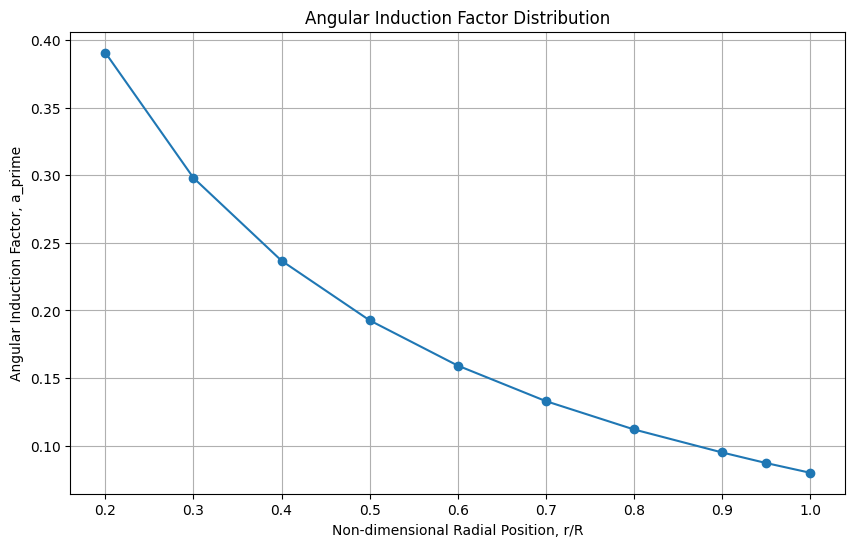

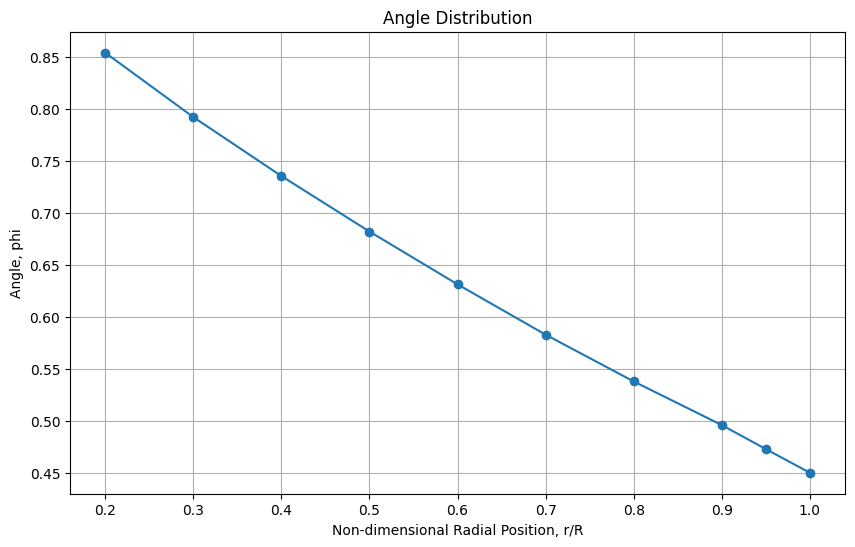

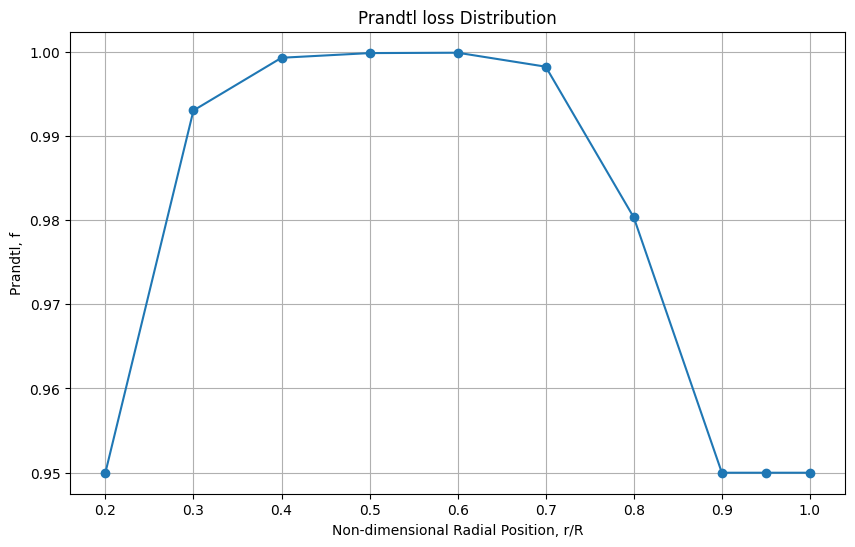

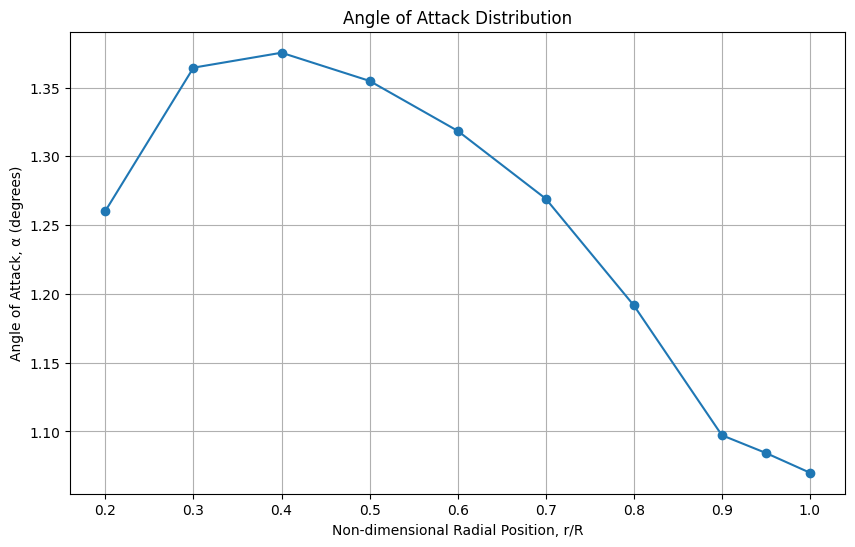

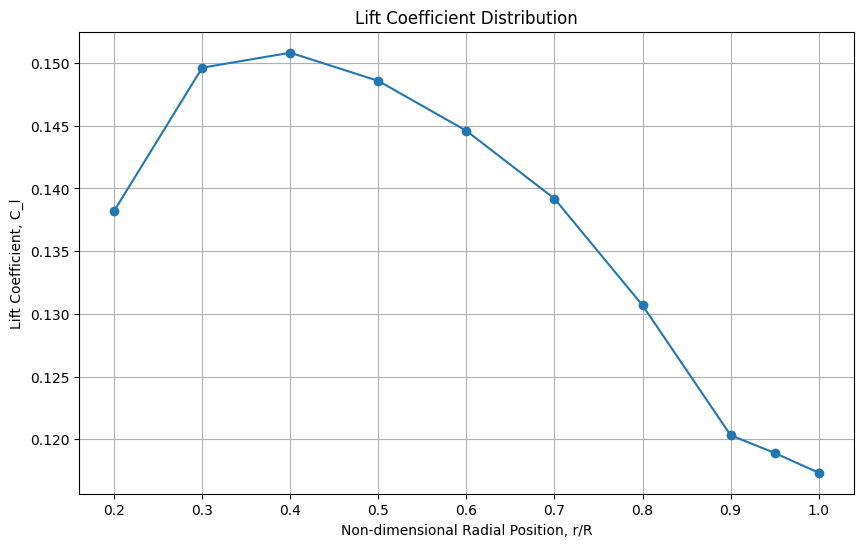

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

def picard_iteration_improved(V_infty, Omega, r, c, beta, N, epsilon=1e-6, max_iter=1000):
    num_annuli = len(r)
    rho = 1025  # Seawater density (kg/m^3)
    C_l_alpha = 2 * np.pi  # Lift curve slope (per radian)
    C_d0 = 0.008  # Profile drag coefficient at zero lift
    k = 0.01  # Quadratic drag coefficient factor
    R = r[-1]  # Propeller maximum radius
    r_hub = r[0]  # Hub radius
    dr = np.diff(r, append=r[-1] - r[-2])  # Ensure consistent spacing for last element

    # Initialize variables and arrays
    a = 0.1 * np.ones(num_annuli)
    a_prime = 0.01 * np.ones(num_annuli)
    phi = np.arctan2(V_infty, Omega * r)
    f = np.ones(num_annuli)
    alpha = np.zeros(num_annuli)
    delta_T = np.zeros(num_annuli)  # Initialize total thrust array
    delta_Q = np.zeros(num_annuli)  # Initialize total torque array

    relaxation_factor = 0.4  # Under-relaxation factor

    # Middle annulus index
    mid_index = num_annuli // 2

    # Function to solve for each annulus
    def solve_annulus(i, a_prev, a_prime_prev, phi_prev):
        # Initialize local variables to store thrust and torque for this annulus
        local_delta_T = 0
        local_delta_Q = 0

        for n_iter in range(max_iter):
            numerator = V_infty * (1 - a_prev)
            denominator = Omega * r[i] * (1 + a_prime_prev)
            if abs(denominator) > 1e-6:
                phi[i] = np.arctan2(numerator, denominator)
            else:
                phi[i] += 1e-6  # adjust slightly instead of setting to a fixed small value

            # Avoid division by zero in phi
            if np.abs(np.sin(phi[i])) < 1e-6:
                phi[i] = phi[i] + 1e-6

            # Compute relative wind speed
            W = np.sqrt(numerator**2 + denominator**2)

            # Recalculate angle of attack and lift/drag coefficients
            alpha[i] = phi[i] - beta[i]
            C_l = C_l_alpha * alpha[i]
            C_d = C_d0 + k * C_l**2

            # Compute elemental thrust and torque
            delta_T[i] = 0.5 * rho * W**2 * N * c[i] * (C_l * np.cos(phi[i]) - C_d * np.sin(phi[i])) * dr[i]
            delta_Q[i] = 0.5 * rho * W**2 * N * c[i] * (C_l * np.sin(phi[i]) + C_d * np.cos(phi[i])) * r[i] * dr[i]

            # Compute Prandtl's loss factor
            f_tip_exp = - (N / 2) * (R - r[i]) / (r[i] * np.sin(phi[i]))
            f_root_exp = - (N / 2) * (r[i] - r_hub) / (r[i] * np.sin(phi[i]))

            f_tip = (2 / np.pi) * np.arccos(np.clip(np.exp(f_tip_exp), 0.0, 1.0))
            f_root = (2 / np.pi) * np.arccos(np.clip(np.exp(f_root_exp), 0.0, 1.0))

            f[i] = f_tip * f_root
            f[i] = np.clip(f[i], 0.95, 1.0)

            # Compute sigma
            sigma_i = (N * c[i]) / (2 * np.pi * r[i])

            # Update a and a_prime
            K = (C_l * sigma_i) / (4 * f[i] * np.sin(phi[i])**2)
            a_new = K / (1 + K)
            K_prime = (C_l * sigma_i) / (4 * f[i] * np.sin(phi[i]) * np.cos(phi[i]))
            a_prime_new = K_prime / (1 + K_prime)

            # Apply under-relaxation
            a[i] = a_prev + relaxation_factor * (a_new - a_prev)
            a_prime[i] = a_prime_prev + relaxation_factor * (a_prime_new - a_prime_prev)

            # Constrain a and a'
            a[i] = np.clip(a[i], 0.0, 1.5)
            a_prime[i] = np.clip(a_prime[i], 0.0, 1.5)

            # Log output for debugging
            print(f"Iteration {n_iter}, Annulus {i}, Phi: {phi[i]:.6f}, a: {a[i]:.6f}, a': {a_prime[i]:.6f}, f': {f[i]:.6f}")

            # Check convergence
            if np.abs(a[i] - a_prev) < epsilon and np.abs(a_prime[i] - a_prime_prev) < epsilon:
                break

            # Update previous values
            a_prev = a[i]
            a_prime_prev = a_prime[i]

        # Update global arrays after the loop for each annulus
        delta_T[i] = local_delta_T
        delta_Q[i] = local_delta_Q

    # Propagate solutions from the middle annulus to the tip and root
    solve_annulus(mid_index, a[mid_index], a_prime[mid_index], phi[mid_index])
    for i in range(mid_index - 1, -1, -1):  # Rootward
        solve_annulus(i, a[i + 1], a_prime[i + 1], phi[i + 1])
    for i in range(mid_index + 1, num_annuli):  # Tipward
        solve_annulus(i, a[i - 1], a_prime[i - 1], phi[i - 1])

    # Calculate total thrust and torque after all annuli are processed
    T = np.sum(delta_T)
    Q = np.sum(delta_Q)

    # Compute non-dimensional coefficients and efficiency
    D = 2 * R
    K_T = T / (rho * n**2 * D**4)
    K_Q = Q / (rho * n**2 * D**5)
    J = V_infty / (n * D)
    eta = (J * K_T) / (2 * np.pi * K_Q)

    return a, a_prime, phi, f, T, Q, K_T, K_Q, J, eta, alpha


# Implement and use the function with your data
data_str = """r_R,c_D,P_D,beta_deg,t_M_c,f_M_c
0.2,0.40,1.100,5,0.2055,0.01429
0.3,0.39,1.100,5,0.1553,0.02318
0.4,0.38,1.100,5,0.1180,0.02303
0.5,0.37,1.100,5,0.09016,0.02182
0.6,0.36,1.100,5,0.06960,0.02072
0.7,0.35,1.100,5,0.05418,0.02003
0.8,0.34,1.100,5,0.04206,0.01967
0.9,0.33,1.100,5,0.03321,0.01817
0.95,0.32,1.100,5,0.03228,0.01631
1.0,0.31,1.100,5,0.03160,0.01175"""
data = pd.read_csv(StringIO(data_str))
V_infty = 3.0
Omega = 2 * np.pi * 15
r = data['r_R'].values * 0.1525
c = data['c_D'].values * 0.305
beta = np.radians(data['beta_deg'].values)
N = 3

a, a_prime, phi, f, T, Q, K_T, K_Q, J, eta, alpha = picard_iteration_improved(V_infty, Omega, r, c, beta, N)

print(f"Total Thrust, T = {T:.2f} N")
print(f"Total Torque, Q = {Q:.2f} Nm")
print(f"Thrust Coefficient, K_T = {K_T:.5f}")
print(f"Torque Coefficient, K_Q = {K_Q:.5f}")
print(f"Advance Coefficient, J = {J:.3f}")
print(f"Propeller Efficiency, η = {eta:.3f}")

# Plot axial induction factor along the blade
plt.figure(figsize=(10, 6))
plt.plot(r_R, a, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Axial Induction Factor, a')
plt.title('Axial Induction Factor Distribution')
plt.grid(True)
plt.show()

# Plot angular induction factor along the blade
plt.figure(figsize=(10, 6))
plt.plot(r_R, a_prime, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Angular Induction Factor, a_prime')
plt.title('Angular Induction Factor Distribution')
plt.grid(True)
plt.show()

# Plot phi angle along the blade
plt.figure(figsize=(10, 6))
plt.plot(r_R, a, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Angle, phi')
plt.title('Angle Distribution')
plt.grid(True)
plt.show()

# Plot phi angle along the blade
plt.figure(figsize=(10, 6))
plt.plot(r_R, f, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Prandtl, f')
plt.title('Prandtl loss Distribution')
plt.grid(True)
plt.show()

# Plot angle of attack distribution
plt.figure(figsize=(10, 6))
plt.plot(r_R, np.degrees(alpha), marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Angle of Attack, α (degrees)')
plt.title('Angle of Attack Distribution')
plt.grid(True)
plt.show()

# Plot lift coefficient distribution
C_l = C_l_alpha * alpha  # Recalculate lift coefficient distribution
plt.figure(figsize=(10, 6))
plt.plot(r_R, C_l, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Lift Coefficient, C_l')
plt.title('Lift Coefficient Distribution')
plt.grid(True)
plt.show()

# Calculation of lift and drag via FEniCs


In [ ]:
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin
try:
    import gmsh
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/gmsh-install.sh" -O "/tmp/gmsh-install.sh" && bash "/tmp/gmsh-install.sh"
    import gmsh
!pip install meshio[all]

In [37]:

def naca4(number, num_points=100):
    m = float(number[0]) / 100.0
    p = float(number[1]) / 10.0
    t = float(number[2:]) / 100.0

    x = np.linspace(0, 1, num_points)
    yt = 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1015 * x**4)  # Thickness distribution
    yc = np.where(x < p, m / p**2 * (2 * p * x - x**2), m / (1 - p)**2 * ((1 - 2 * p) + 2 * p * x - x**2))  # Camber line
    dyc_dx = np.where(x < p, 2 * m / p**2 * (p - x), 2 * m / (1 - p)**2 * (p - x))  # Camber line slope
    theta = np.arctan(dyc_dx)

    xu = x - yt * np.sin(theta)  # Upper surface x-coordinates
    yu = yc + yt * np.cos(theta)  # Upper surface y-coordinates
    xl = x + yt * np.sin(theta)  # Lower surface x-coordinates
    yl = yc - yt * np.cos(theta)  # Lower surface y-coordinates

    # Combine upper and lower surfaces
    x_combined = np.concatenate([xu[::-1], xl[1:]])
    y_combined = np.concatenate([yu[::-1], yl[1:]])

    # Compute the chord length as the distance from leading edge to trailing edge (max x - min x)
    chord_length = np.max(x_combined) - np.min(x_combined)

    return x_combined, y_combined, chord_length

In [38]:
import numpy as np
from dolfin import *
from mshr import *

# Define mesh around airfoil
# Generate airfoil coordinates
airfoil_x, airfoil_y, chord_length = naca4("2412", num_points=200)

# Define a bounding box that encloses the airfoil (adjust the limits if necessary)
x_min, x_max = min(airfoil_x) - 0.01, max(airfoil_x) + 0.01
y_min, y_max = min(airfoil_y) - 0.01, max(airfoil_y) + 0.01

# Define a SubDomain for the airfoil boundary based on the bounding box
class AirfoilBoundary(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and (x_min < x[0] < x_max) and (y_min < x[1] < y_max)

airfoil_domain = AirfoilBoundary()

# Create mesh and define function space
domain = Rectangle(Point(-2, -2), Point(3, 2))
mesh = generate_mesh(domain - Polygon([Point(x, y) for x, y in zip(airfoil_x, airfoil_y)]), 20)

# Define MeshFunction for boundary markers
boundary_markers = MeshFunction("size_t", mesh, mesh.topology().dim()-1, 0)

# Mark the airfoil boundary with a specific marker (e.g., 1)
airfoil_domain.mark(boundary_markers, 1)

In [ ]:
mesh

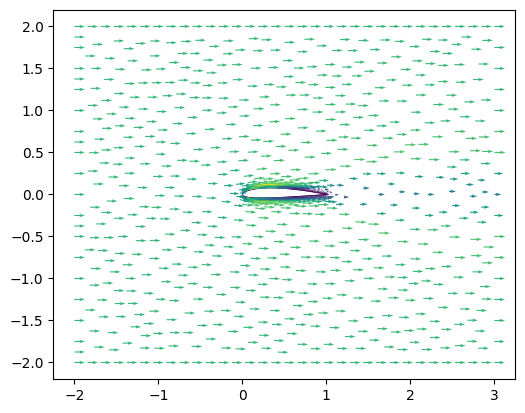

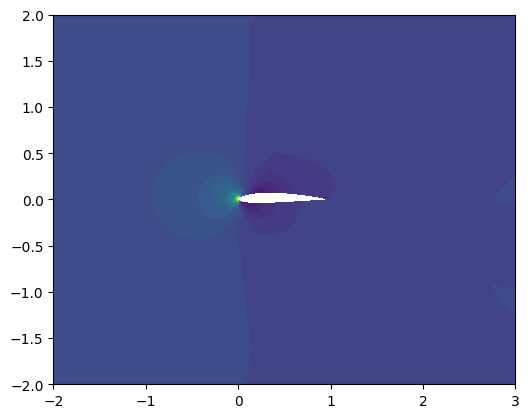

Fx = -0.37590010695567166 Fy = 0.012409097562418425 v_max = 14.578702096480004
Lift coefficient (Cl) = 0.0002068009599009865
Drag coefficient (Cd) = -0.006264476732034511


In [41]:
"""
FEniCS tutorial demo program: Incompressible Navier-Stokes equations
for flow around a cylinder using the Incremental Pressure Correction
Scheme (IPCS).

  u' + u . nabla(u)) - div(sigma(u, p)) = f
                                            div(u) = 0
"""

import time # Import the time module
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

###############################################################################
###############################################################################
############################ Own functions ####################################

#Computation time
start = time.time()
iterTime = start

#Case setting
Umean = 10              # Air velocity
alpha = 0
U_infty = Constant((Umean*np.cos(alpha),Umean*np.sin(alpha)))

#Fluid's parameters
mu = 18e-6          # dynamic viscosity
rho_value = 1.2               # density
Beta = 1.0      # 0 for Picard - 1 for Newton-Raphson
f  = Constant((0, 0))
mu = Constant(mu)
rho = Constant(rho_value)
Cp = Constant(Cp)
Beta = Constant(Beta)
alpha = Constant(alpha)

#VMS
C1 = Constant(4.0)
C2 = Constant(2.0)
C3 = Constant(1.0)
C4 = Constant(1.0)


#######################################################################################
#
############################## Initial conditions ############################

class InitialCondition(UserExpression):
    def eval(self, values, x):
        values[0] = 1.0
        values[1] = 0.0
        values[2] = 0.0
    def value_shape(self):
        return (3,)

ic=InitialCondition(degree =2)

############################################################################
######################## Tensor and Matrix operations ######################

# Define symmetric gradient
def epsilon(u):
     return sym(nabla_grad(u))

def convective(u1,u2):
    return dot(u1, nabla_grad(u2))

############################################################################
################################## Matrix ##################################

# Galerkin Termns:
def MAT_Gh(u, v, p, q):
    return 2.0*mu*inner(epsilon(u), epsilon(v))*dx  \
              - p*div(v)*dx \
              + q*div(u)*dx

# NonLinear Terms:
def MAT_NLh(u, u_n, v, Beta):
    return Beta * inner( rho * convective(u,u_n), v )*dx \
                + inner( rho * convective(u_n,u), v )*dx

# Stabilization Terms:
def MAT_VMSh(u, u_n, v, p, q, Tau1, Tau2):
    return  Tau1 * inner( rho * convective(u_n,v) + nabla_grad(q), rho * convective(u_n,u)+nabla_grad(p) )*dx \
            + Tau2 * div(v)*div(u)*dx

############################################################################
################################## RHS  ####################################

# Galerkin Termns:
# v * f
def VECT_Gh(v, f):
    return inner( v,f )*dx

# NonLinear Terms:
def VECT_NLh(u_n, v, Beta):
    return Beta*inner(rho * convective(u_n,u_n), v)*dx

# Stabilization Terms:
def VECT_VMSh(u_n,v,q,Tau1,f):
    return Tau1 * rho * inner( convective(u_n,v),f)*dx \
          + Tau1 * inner( nabla_grad(q),f)*dx

############################################################################
########################### Build function space ###########################

P2 = VectorElement("P", mesh.ufl_cell(), 1) #Second order for velocity
P1 = FiniteElement("P", mesh.ufl_cell(), 1) #First order for pressure
TH = MixedElement([P2, P1])
W = FunctionSpace(mesh, TH)   #Our functional space
Q = FunctionSpace(mesh, P1)   #Our functional space

# Define functions for solutions at previous and current time steps

# For linear system
U = Function(W)
DU = TrialFunction(W)

bcs = list()
bcs.append(DirichletBC(W.sub(0), U_infty, 'near(x[0], -2)'))
bcs.append(DirichletBC(W.sub(1), Constant(0.), "near(x[1],-2) || near(x[1],2)"))
bcs.append(DirichletBC(W.sub(1), Constant(0.), "near(x[0],3.0)"))
bcs.append(DirichletBC(W.sub(0), Constant((0, 0)), boundary_markers, 1))

ds=Measure("ds", domain=mesh, subdomain_data=boundary_markers)
n = FacetNormal(mesh)
# Non-linear and old solutions
U_n = Function(W)
U_n.assign(interpolate(ic,W))

# Define trial and test functions
(u,p) = split(U)
(v,q) = TestFunctions(W)

# Get sub-functions
u_n, p_n = split(U_n)

# Define facet normal and mesh size
h = 2.0*Circumradius(mesh)

############################################################################
############# Calculate mesh dependent algorithmic parameters ##############
############################################################################

vnorm = sqrt(dot(u_n, u_n))

# VMS Stabilization terms
Tau1 = C1*mu/h**2.0 + C2*rho*vnorm/h
Tau1 = 1.0 / Tau1
Tau2 = C3*mu + C4*rho*vnorm*h

############################################################################
############################################################################

a = MAT_Gh(u, v, p, q) \
  + MAT_NLh(u, u_n, v, Beta) \
   + MAT_VMSh(u, u_n, v, p, q, Tau1, Tau2)

L = VECT_Gh(v, f) \
  + VECT_NLh(u_n, v, Beta) \
  + VECT_VMSh(u_n, v, q, Tau1,f)

F = a - L

drag=[]
def sigma(u, p):
    return 2*mu*epsilon(u) - p*Identity(u.geometric_dimension())

# Solve variational problem for time step
J = derivative(F, U, DU) #Define the Jacobian
problem = NonlinearVariationalProblem(F, U, bcs,J)
solver = NonlinearVariationalSolver(problem)
prm = solver.parameters
prm['newton_solver']['absolute_tolerance'] = 1E-10
prm['newton_solver']['relative_tolerance'] = 1E-7
prm['newton_solver']['maximum_iterations'] = 25
prm['newton_solver']['relaxation_parameter'] = 1.0
prm['newton_solver']['linear_solver'] = 'mumps'

begin("Solving transport...")
solver.solve()
end()

(u,p)=U.split(True)

# Create XDMF files for visualization output
xdmffile_u = XDMFFile('velocity.xdmf')
xdmffile_p = XDMFFile('pressure.xdmf')
xdmffile_m = XDMFFile('markers.xdmf')
xdmffile_u.parameters["flush_output"] = True
xdmffile_u.parameters["functions_share_mesh"] = True
xdmffile_u.parameters["rewrite_function_mesh"] = False
xdmffile_p.parameters["flush_output"] = True
xdmffile_p.parameters["functions_share_mesh"] = True
xdmffile_p.parameters["rewrite_function_mesh"] = False
xdmffile_m.parameters["flush_output"] = True
xdmffile_m.parameters["functions_share_mesh"] = True
xdmffile_m.parameters["rewrite_function_mesh"] = False


# Save solution to file (XDMF/HDF5)
xdmffile_u.write(u)
xdmffile_p.write(p)

plot(u)
plt.show()
plot(p)
plt.show()

force = dot(sigma(u,p),n)
Fx=assemble(force[0]*ds(1))
Fy=assemble(force[1]*ds(1))
drag.append([Fx,Fy])
dir(u)
print(f'Fx = {Fx} Fy = {Fy} v_max = {u.vector().max()}')
data=pd.DataFrame(drag,columns=['Fx','Fy'])
data.to_csv('data.csv')

# Compute dynamic pressure
q = 0.5 * rho_value * Umean**2

# Compute lift and drag coefficients
Cl = Fy / (q * chord_length)
Cd = Fx / (q * chord_length)

# Print results
print(f'Lift coefficient (Cl) = {Cl}')
print(f'Drag coefficient (Cd) = {Cd}')

## Encapsulated BEMT + FEniCS solution

In [42]:
def naca4(number, num_points=100):
    m = float(number[0]) / 100.0
    p = float(number[1]) / 10.0
    t = float(number[2:]) / 100.0

    x = np.linspace(0, 1, num_points)
    yt = 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1015 * x**4)  # Thickness distribution
    yc = np.where(x < p, m / p**2 * (2 * p * x - x**2), m / (1 - p)**2 * ((1 - 2 * p) + 2 * p * x - x**2))  # Camber line
    dyc_dx = np.where(x < p, 2 * m / p**2 * (p - x), 2 * m / (1 - p)**2 * (p - x))  # Camber line slope
    theta = np.arctan(dyc_dx)

    xu = x - yt * np.sin(theta)  # Upper surface x-coordinates
    yu = yc + yt * np.cos(theta)  # Upper surface y-coordinates
    xl = x + yt * np.sin(theta)  # Lower surface x-coordinates
    yl = yc - yt * np.cos(theta)  # Lower surface y-coordinates

    # Combine upper and lower surfaces
    x_combined = np.concatenate([xu[::-1], xl[1:]])
    y_combined = np.concatenate([yu[::-1], yl[1:]])

    # Compute the chord length as the distance from leading edge to trailing edge (max x - min x)
    chord_length = np.max(x_combined) - np.min(x_combined)

    return x_combined, y_combined, chord_length

In [48]:
import time
import numpy as np
from dolfin import *
from mshr import *
import matplotlib.pyplot as plt
import pandas as pd

def compute_lift_drag(naca_code, wind_velocity, angle_of_attack):
    # Generate airfoil coordinates and chord length
    airfoil_x, airfoil_y, chord_length = naca4(naca_code, num_points=200)

    # Define a bounding box that encloses the airfoil
    x_min, x_max = min(airfoil_x) - 0.01, max(airfoil_x) + 0.01
    y_min, y_max = min(airfoil_y) - 0.01, max(airfoil_y) + 0.01

    # Define a SubDomain for the airfoil boundary based on the bounding box
    class AirfoilBoundary(SubDomain):
        def inside(self, x, on_boundary):
            return on_boundary and (x_min < x[0] < x_max) and (y_min < x[1] < y_max)

    airfoil_domain = AirfoilBoundary()

    # Create mesh and define function space
    domain = Rectangle(Point(-2, -2), Point(3, 2))
    mesh = generate_mesh(domain - Polygon([Point(x, y) for x, y in zip(airfoil_x, airfoil_y)]), 20)

    # Define MeshFunction for boundary markers
    boundary_markers = MeshFunction("size_t", mesh, mesh.topology().dim()-1, 0)
    airfoil_domain.mark(boundary_markers, 1)

    # Set wind velocity and angle of attack
    Umean = wind_velocity
    alpha = angle_of_attack
    U_infty = Constant((Umean * np.cos(alpha), Umean * np.sin(alpha)))

    # Fluid parameters
    mu_value = 18e-6          # dynamic viscosity
    rho_value = 1.2           # density
    f = Constant((0, 0))      # external forces (zero for now)
    mu = Constant(mu_value)
    rho = Constant(rho_value)

    #VMS
    C1 = Constant(4.0)
    C2 = Constant(2.0)
    C3 = Constant(1.0)
    C4 = Constant(1.0)


    #######################################################################################
    #
    ############################## Initial conditions ############################

    class InitialCondition(UserExpression):
        def eval(self, values, x):
            values[0] = 1.0
            values[1] = 0.0
            values[2] = 0.0
        def value_shape(self):
            return (3,)

    ic=InitialCondition(degree =2)

    ############################################################################
    ######################## Tensor and Matrix operations ######################

    # Define symmetric gradient
    def epsilon(u):
        return sym(nabla_grad(u))

    def convective(u1,u2):
        return dot(u1, nabla_grad(u2))

    ############################################################################
    ################################## Matrix ##################################

    # Galerkin Termns:
    def MAT_Gh(u, v, p, q):
        return 2.0*mu*inner(epsilon(u), epsilon(v))*dx  \
                  - p*div(v)*dx \
                  + q*div(u)*dx

    # NonLinear Terms:
    def MAT_NLh(u, u_n, v, Beta):
        return Beta * inner( rho * convective(u,u_n), v )*dx \
                    + inner( rho * convective(u_n,u), v )*dx

    # Stabilization Terms:
    def MAT_VMSh(u, u_n, v, p, q, Tau1, Tau2):
        return  Tau1 * inner( rho * convective(u_n,v) + nabla_grad(q), rho * convective(u_n,u)+nabla_grad(p) )*dx \
                + Tau2 * div(v)*div(u)*dx

    ############################################################################
    ################################## RHS  ####################################

    # Galerkin Termns:
    # v * f
    def VECT_Gh(v, f):
        return inner( v,f )*dx

    # NonLinear Terms:
    def VECT_NLh(u_n, v, Beta):
        return Beta*inner(rho * convective(u_n,u_n), v)*dx

    # Stabilization Terms:
    def VECT_VMSh(u_n,v,q,Tau1,f):
        return Tau1 * rho * inner( convective(u_n,v),f)*dx \
              + Tau1 * inner( nabla_grad(q),f)*dx

    ############################################################################
    ########################### Build function space ###########################

    P2 = VectorElement("P", mesh.ufl_cell(), 1) #Second order for velocity
    P1 = FiniteElement("P", mesh.ufl_cell(), 1) #First order for pressure
    TH = MixedElement([P2, P1])
    W = FunctionSpace(mesh, TH)   #Our functional space
    Q = FunctionSpace(mesh, P1)   #Our functional space

    # Define functions for solutions at previous and current time steps

    # For linear system
    U = Function(W)
    DU = TrialFunction(W)

    bcs = list()
    bcs.append(DirichletBC(W.sub(0), U_infty, 'near(x[0], -2)'))
    bcs.append(DirichletBC(W.sub(1), Constant(0.), "near(x[1],-2) || near(x[1],2)"))
    bcs.append(DirichletBC(W.sub(1), Constant(0.), "near(x[0],3.0)"))
    bcs.append(DirichletBC(W.sub(0), Constant((0, 0)), boundary_markers, 1))

    ds=Measure("ds", domain=mesh, subdomain_data=boundary_markers)
    n = FacetNormal(mesh)
    # Non-linear and old solutions
    U_n = Function(W)
    U_n.assign(interpolate(ic,W))

    # Define trial and test functions
    (u,p) = split(U)
    (v,q) = TestFunctions(W)

    # Get sub-functions
    u_n, p_n = split(U_n)

    # Define facet normal and mesh size
    h = 2.0*Circumradius(mesh)

    ############################################################################
    ############# Calculate mesh dependent algorithmic parameters ##############
    ############################################################################

    vnorm = sqrt(dot(u_n, u_n))

    # VMS Stabilization terms
    Tau1 = C1*mu/h**2.0 + C2*rho*vnorm/h
    Tau1 = 1.0 / Tau1
    Tau2 = C3*mu + C4*rho*vnorm*h

    ############################################################################
    ############################################################################

    a = MAT_Gh(u, v, p, q) \
      + MAT_NLh(u, u_n, v, Beta) \
      + MAT_VMSh(u, u_n, v, p, q, Tau1, Tau2)

    L = VECT_Gh(v, f) \
      + VECT_NLh(u_n, v, Beta) \
      + VECT_VMSh(u_n, v, q, Tau1,f)

    F = a - L

    drag=[]

    def sigma(u, p):
        return 2*mu*epsilon(u) - p*Identity(u.geometric_dimension())

    # Solve variational problem for time step
    J = derivative(F, U, DU) #Define the Jacobian
    problem = NonlinearVariationalProblem(F, U, bcs,J)
    solver = NonlinearVariationalSolver(problem)
    prm = solver.parameters
    prm['newton_solver']['absolute_tolerance'] = 1E-10
    prm['newton_solver']['relative_tolerance'] = 1E-7
    prm['newton_solver']['maximum_iterations'] = 25
    prm['newton_solver']['relaxation_parameter'] = 1.0
    prm['newton_solver']['linear_solver'] = 'mumps'

    begin("Solving transport...")
    solver.solve()
    end()

    (u,p)=U.split(True)

    force = dot(sigma(u, p), -n)
    Fx = assemble(force[0] * ds(1))
    Fy = assemble(force[1] * ds(1))

    # Compute dynamic pressure
    q = 0.5 * rho_value * Umean**2

    # Compute lift and drag coefficients
    Cl = Fy / (q * chord_length)
    Cd = Fx / (q * chord_length)

    return Cl, Cd

In [49]:
# Example usage:
naca_code = "2412"
wind_velocity = 10.0  # m/s
angle_of_attack = 0.0  # radians
Cl, Cd = compute_lift_drag(naca_code, wind_velocity, angle_of_attack)
print(f"Lift Coefficient (Cl): {Cl}")
print(f"Drag Coefficient (Cd): {Cd}")

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_29c67925a224001c43139af2cfb651cfd68b07da

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:                 2
  Number of exterior_facet subdomains: 2
  Rank:                                0
  Arguments:                           '()'
  Number of coefficients:              3
  Coefficients:                        '[f_4848, f_4859-0, f_4859-1]'
  Unique elements:                     'R0(?,?), Vector<2 x CG1(?,?)>, CG1(?,?)'
  Unique sub elements:                 'R0(?,?), Vector<2 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 1
INFO:FFC:  quadrature_degree:

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_521b8270294ab152f1ec2e845106f5aa6e316483

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:                 2
  Number of exterior_facet subdomains: 2
  Rank:                                0
  Arguments:                           '()'
  Number of coefficients:              3
  Coefficients:                        '[f_4848, f_4859-0, f_4859-1]'
  Unique elements:                     'R0(?,?), Vector<2 x CG1(?,?)>, CG1(?,?)'
  Unique sub elements:                 'R0(?,?), Vector<2 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 1
INFO:FFC:  quadrature_degree:

Lift Coefficient (Cl): -0.0002068009599009865
Drag Coefficient (Cd): 0.006264476732034511


<ipython-input-50-2fc4bec5e966>:117: RuntimeWarning: invalid value encountered in scalar divide
  eta = (J * K_T) / (2 * np.pi * K_Q)


Total Thrust, T = 0.00 N
Total Torque, Q = 0.00 Nm
Thrust Coefficient, K_T = 0.00000
Torque Coefficient, K_Q = 0.00000
Advance Coefficient, J = 0.656
Propeller Efficiency, η = nan


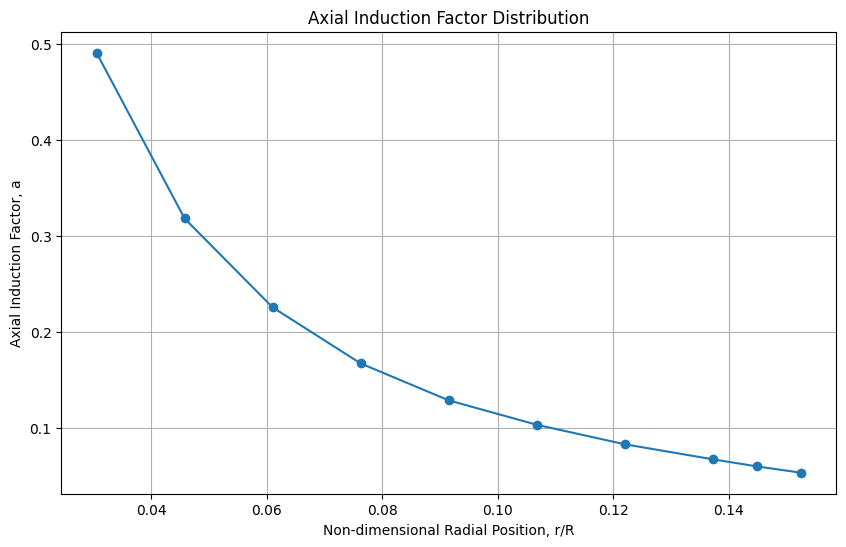

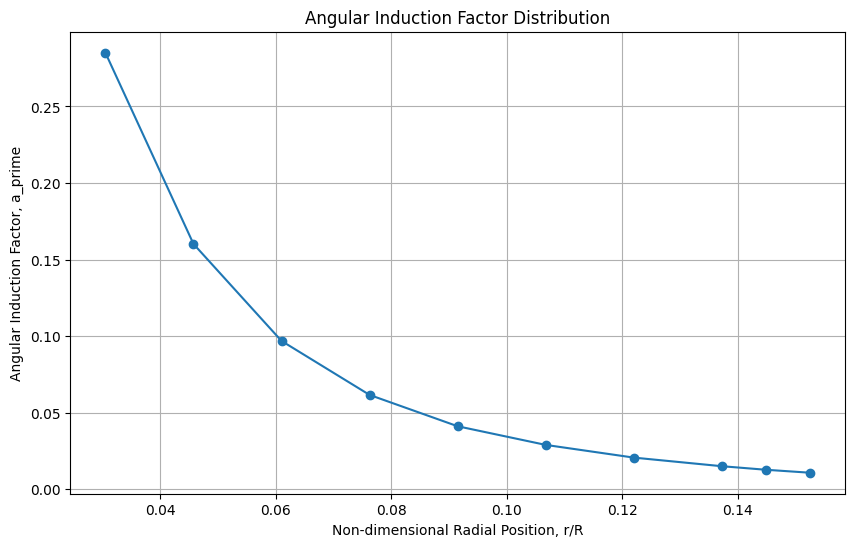

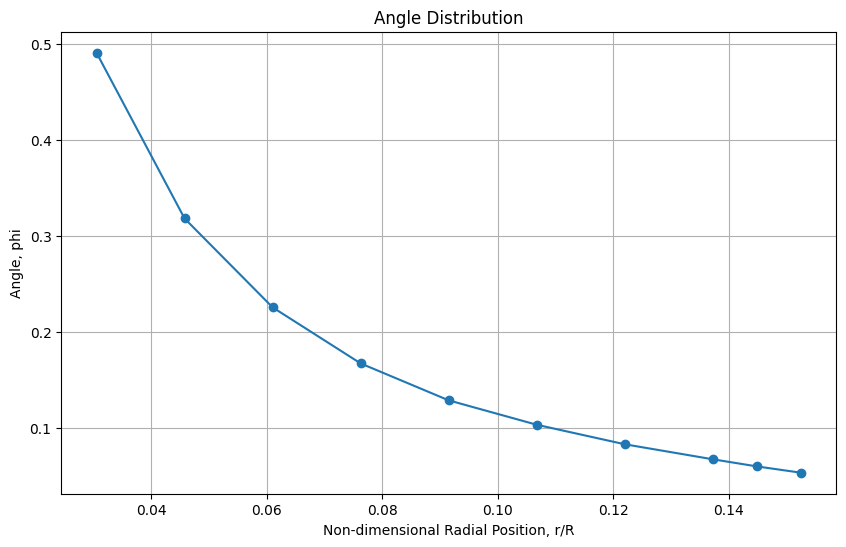

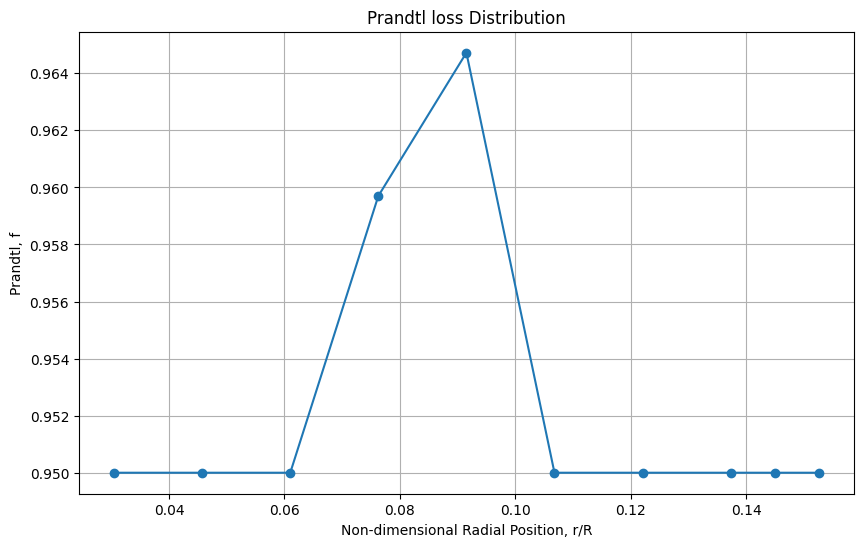

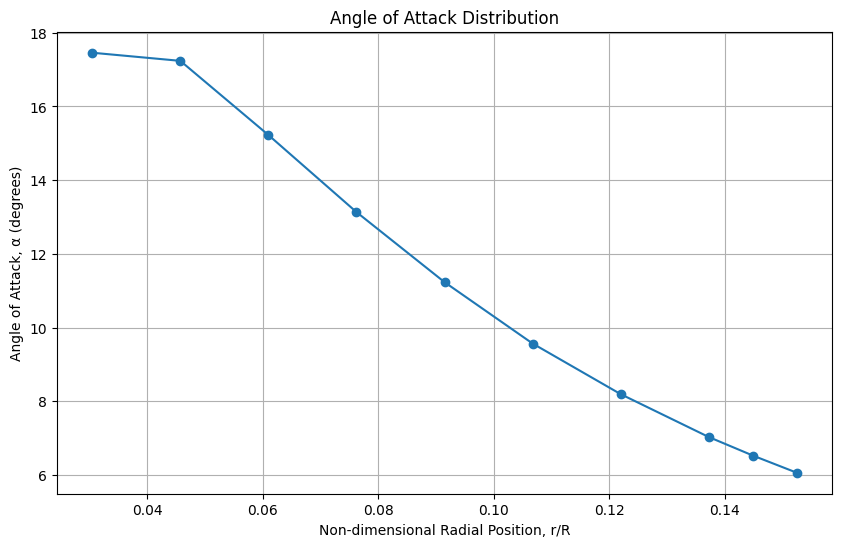

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

def picard_iteration_improved(V_infty, Omega, r, c, beta, N, epsilon=1e-6, max_iter=1000):
    num_annuli = len(r)
    rho = 1025  # Seawater density (kg/m^3)
    C_l_alpha = 2 * np.pi  # Lift curve slope (per radian)
    C_d0 = 0.008  # Profile drag coefficient at zero lift
    k = 0.01  # Quadratic drag coefficient factor
    R = r[-1]  # Propeller maximum radius
    r_hub = r[0]  # Hub radius
    dr = np.diff(r, append=r[-1] - r[-2])  # Ensure consistent spacing for last element

    # Initialize variables and arrays
    a = 0.1 * np.ones(num_annuli)
    a_prime = 0.01 * np.ones(num_annuli)
    phi = np.arctan2(V_infty, Omega * r)
    f = np.ones(num_annuli)
    alpha = np.zeros(num_annuli)
    delta_T = np.zeros(num_annuli)  # Initialize total thrust array
    delta_Q = np.zeros(num_annuli)  # Initialize total torque array

    relaxation_factor = 0.4  # Under-relaxation factor

    # Middle annulus index
    mid_index = num_annuli // 2

    # Function to solve for each annulus
    def solve_annulus(i, a_prev, a_prime_prev, phi_prev):
        # Initialize local variables to store thrust and torque for this annulus
        local_delta_T = 0
        local_delta_Q = 0

        for n_iter in range(max_iter):
            numerator = V_infty * (1 - a_prev)
            denominator = Omega * r[i] * (1 + a_prime_prev)
            if abs(denominator) > 1e-6:
                phi[i] = np.arctan2(numerator, denominator)
            else:
                phi[i] += 1e-6  # adjust slightly instead of setting to a fixed small value

            # Avoid division by zero in phi
            if np.abs(np.sin(phi[i])) < 1e-6:
                phi[i] = phi[i] + 1e-6

            # Compute relative wind speed
            W = np.sqrt(numerator**2 + denominator**2)

            # Recalculate angle of attack
            alpha[i] = phi[i] - beta[i]

            # Calculate lift and drag coefficients using the FEniCS solver
            Cl, Cd = compute_lift_drag("2412", W, alpha[i])

            # Compute elemental thrust and torque using the new Cl and Cd
            delta_T[i] = 0.5 * rho * W**2 * N * c[i] * (Cl * np.cos(phi[i]) - Cd * np.sin(phi[i])) * dr[i]
            delta_Q[i] = 0.5 * rho * W**2 * N * c[i] * (Cl * np.sin(phi[i]) + Cd * np.cos(phi[i])) * r[i] * dr[i]

            # Compute Prandtl's loss factor
            f_tip_exp = - (N / 2) * (R - r[i]) / (r[i] * np.sin(phi[i]))
            f_root_exp = - (N / 2) * (r[i] - r_hub) / (r[i] * np.sin(phi[i]))

            f_tip = (2 / np.pi) * np.arccos(np.clip(np.exp(f_tip_exp), 0.0, 1.0))
            f_root = (2 / np.pi) * np.arccos(np.clip(np.exp(f_root_exp), 0.0, 1.0))

            f[i] = f_tip * f_root
            f[i] = np.clip(f[i], 0.95, 1.0)

            # Compute sigma
            sigma_i = (N * c[i]) / (2 * np.pi * r[i])

            # Update a and a_prime
            K = (Cl * sigma_i) / (4 * f[i] * np.sin(phi[i])**2)
            a_new = K / (1 + K)
            K_prime = (Cl * sigma_i) / (4 * f[i] * np.sin(phi[i]) * np.cos(phi[i]))
            a_prime_new = K_prime / (1 + K_prime)

            # Apply under-relaxation
            a[i] = a_prev + relaxation_factor * (a_new - a_prev)
            a_prime[i] = a_prime_prev + relaxation_factor * (a_prime_new - a_prime_prev)

            # Constrain a and a'
            a[i] = np.clip(a[i], 0.0, 1.5)
            a_prime[i] = np.clip(a_prime[i], 0.0, 1.5)

            # Check convergence
            if np.abs(a[i] - a_prev) < epsilon and np.abs(a_prime[i] - a_prime_prev) < epsilon:
                break

            # Update previous values
            a_prev = a[i]
            a_prime_prev = a_prime[i]

        # Update global arrays after the loop for each annulus
        delta_T[i] = local_delta_T
        delta_Q[i] = local_delta_Q

    # Propagate solutions from the middle annulus to the tip and root
    solve_annulus(mid_index, a[mid_index], a_prime[mid_index], phi[mid_index])
    for i in range(mid_index - 1, -1, -1):  # Rootward
        solve_annulus(i, a[i + 1], a_prime[i + 1], phi[i + 1])
    for i in range(mid_index + 1, num_annuli):  # Tipward
        solve_annulus(i, a[i - 1], a_prime[i - 1], phi[i - 1])

    # Calculate total thrust and torque after all annuli are processed
    T = np.sum(delta_T)
    Q = np.sum(delta_Q)

    # Compute non-dimensional coefficients and efficiency
    D = 2 * R
    rotational_speed = Omega / (2 * np.pi)  # Rename from n to avoid conflicts
    K_T = T / (rho * rotational_speed**2 * D**4)
    K_Q = Q / (rho * rotational_speed**2 * D**5)
    J = V_infty / (rotational_speed * D)
    eta = (J * K_T) / (2 * np.pi * K_Q)

    return a, a_prime, phi, f, T, Q, K_T, K_Q, J, eta, alpha

# Implement and use the function with your data
data_str = """r_R,c_D,P_D,beta_deg,t_M_c,f_M_c
0.2,0.40,1.100,5,0.2055,0.01429
0.3,0.39,1.100,5,0.1553,0.02318
0.4,0.38,1.100,5,0.1180,0.02303
0.5,0.37,1.100,5,0.09016,0.02182
0.6,0.36,1.100,5,0.06960,0.02072
0.7,0.35,1.100,5,0.05418,0.02003
0.8,0.34,1.100,5,0.04206,0.01967
0.9,0.33,1.100,5,0.03321,0.01817
0.95,0.32,1.100,5,0.03228,0.01631
1.0,0.31,1.100,5,0.03160,0.01175"""
data = pd.read_csv(StringIO(data_str))
V_infty = 3.0
Omega = 2 * np.pi * 15
r = data['r_R'].values * 0.1525
c = data['c_D'].values * 0.305
beta = np.radians(data['beta_deg'].values)
N = 3

a, a_prime, phi, f, T, Q, K_T, K_Q, J, eta, alpha = picard_iteration_improved(V_infty, Omega, r, c, beta, N)

print(f"Total Thrust, T = {T:.5f} N")
print(f"Total Torque, Q = {Q:.5f} Nm")
print(f"Thrust Coefficient, K_T = {K_T:.5f}")
print(f"Torque Coefficient, K_Q = {K_Q:.5f}")
print(f"Advance Coefficient, J = {J:.5f}")
print(f"Propeller Efficiency, η = {eta:.5f}")

# Plot axial induction factor along the blade
plt.figure(figsize=(10, 6))
plt.plot(r, a, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Axial Induction Factor, a')
plt.title('Axial Induction Factor Distribution')
plt.grid(True)
plt.show()

# Plot angular induction factor along the blade
plt.figure(figsize=(10, 6))
plt.plot(r, a_prime, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Angular Induction Factor, a_prime')
plt.title('Angular Induction Factor Distribution')
plt.grid(True)
plt.show()

# Plot phi angle along the blade
plt.figure(figsize=(10, 6))
plt.plot(r, a, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Angle, phi')
plt.title('Angle Distribution')
plt.grid(True)
plt.show()

# Plot phi angle along the blade
plt.figure(figsize=(10, 6))
plt.plot(r, f, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Prandtl, f')
plt.title('Prandtl loss Distribution')
plt.grid(True)
plt.show()

# Plot angle of attack distribution
plt.figure(figsize=(10, 6))
plt.plot(r, np.degrees(alpha), marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Angle of Attack, α (degrees)')
plt.title('Angle of Attack Distribution')
plt.grid(True)
plt.show()

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# Define your FEniCS-based lift/drag computation function here (compute_lift_drag)

def picard_iteration_improved(V_infty, Omega, r, c, beta, naca_profiles, N, epsilon=1e-6, max_iter=1000):
    num_annuli = len(r)
    rho = 1025  # Seawater density (kg/m^3)
    R = r[-1]  # Propeller maximum radius
    r_hub = r[0]  # Hub radius
    dr = np.diff(r, append=r[-1] - r[-2])  # Ensure consistent spacing for last element

    # Initialize variables and arrays
    a = 0.1 * np.ones(num_annuli)
    a_prime = 0.01 * np.ones(num_annuli)
    phi = np.arctan2(V_infty, Omega * r)
    f = np.ones(num_annuli)
    alpha = np.zeros(num_annuli)
    delta_T = np.zeros(num_annuli)  # Initialize total thrust array
    delta_Q = np.zeros(num_annuli)  # Initialize total torque array

    relaxation_factor = 0.4  # Under-relaxation factor

    # Middle annulus index
    mid_index = num_annuli // 2

    # Function to solve for each annulus
    def solve_annulus(i, a_prev, a_prime_prev, phi_prev):
        # Initialize local variables to store thrust and torque for this annulus
        local_delta_T = 0
        local_delta_Q = 0

        for n_iter in range(max_iter):
            numerator = V_infty * (1 - a_prev)
            denominator = Omega * r[i] * (1 + a_prime_prev)
            if abs(denominator) > 1e-6:
                phi[i] = np.arctan2(numerator, denominator)
            else:
                phi[i] += 1e-6  # adjust slightly instead of setting to a fixed small value

            # Avoid division by zero in phi
            if np.abs(np.sin(phi[i])) < 1e-6:
                phi[i] = phi[i] + 1e-6

            # Compute relative wind speed
            W = np.sqrt(numerator**2 + denominator**2)

            # Recalculate angle of attack
            alpha[i] = phi[i] - beta[i]

            # Use the specific NACA profile for this section
            naca_profile = naca_profiles[i]

            # Call the FEniCS-based function for lift and drag coefficients
            Cl, Cd = compute_lift_drag(naca_profile, W, alpha[i])

            # Compute elemental thrust and torque using the new Cl and Cd
            delta_T[i] = 0.5 * rho * W**2 * N * c[i] * (Cl * np.cos(phi[i]) - Cd * np.sin(phi[i])) * dr[i]
            delta_Q[i] = 0.5 * rho * W**2 * N * c[i] * (Cl * np.sin(phi[i]) + Cd * np.cos(phi[i])) * r[i] * dr[i]

            # Compute Prandtl's loss factor
            f_tip_exp = - (N / 2) * (R - r[i]) / (r[i] * np.sin(phi[i]))
            f_root_exp = - (N / 2) * (r[i] - r_hub) / (r[i] * np.sin(phi[i]))

            f_tip = (2 / np.pi) * np.arccos(np.clip(np.exp(f_tip_exp), 0.0, 1.0))
            f_root = (2 / np.pi) * np.arccos(np.clip(np.exp(f_root_exp), 0.0, 1.0))

            f[i] = f_tip * f_root
            f[i] = np.clip(f[i], 0.95, 1.0)

            # Compute sigma
            sigma_i = (N * c[i]) / (2 * np.pi * r[i])

            # Update a and a_prime
            K = (Cl * sigma_i) / (4 * f[i] * np.sin(phi[i])**2)
            a_new = K / (1 + K)
            K_prime = (Cl * sigma_i) / (4 * f[i] * np.sin(phi[i]) * np.cos(phi[i]))
            a_prime_new = K_prime / (1 + K_prime)

            # Apply under-relaxation
            a[i] = a_prev + relaxation_factor * (a_new - a_prev)
            a_prime[i] = a_prime_prev + relaxation_factor * (a_prime_new - a_prime_prev)

            # Constrain a and a'
            a[i] = np.clip(a[i], 0.0, 1.5)
            a_prime[i] = np.clip(a_prime[i], 0.0, 1.5)

            # Check convergence
            if np.abs(a[i] - a_prev) < epsilon and np.abs(a_prime[i] - a_prime_prev) < epsilon:
                break

            # Update previous values
            a_prev = a[i]
            a_prime_prev = a_prime[i]

        # Update global arrays after the loop for each annulus
        delta_T[i] = local_delta_T
        delta_Q[i] = local_delta_Q

    # Propagate solutions from the middle annulus to the tip and root
    solve_annulus(mid_index, a[mid_index], a_prime[mid_index], phi[mid_index])
    for i in range(mid_index - 1, -1, -1):  # Rootward
        solve_annulus(i, a[i + 1], a_prime[i + 1], phi[i + 1])
    for i in range(mid_index + 1, num_annuli):  # Tipward
        solve_annulus(i, a[i - 1], a_prime[i - 1], phi[i - 1])

    # Calculate total thrust and torque after all annuli are processed
    T = np.sum(delta_T)
    Q = np.sum(delta_Q)

    # Compute non-dimensional coefficients and efficiency
    D = 2 * R
    rotational_speed = Omega / (2 * np.pi)  # Rename from n to avoid conflicts
    K_T = T / (rho * rotational_speed**2 * D**4)
    K_Q = Q / (rho * rotational_speed**2 * D**5)
    J = V_infty / (rotational_speed * D)
    eta = (J * K_T) / (2 * np.pi * K_Q)

    return a, a_prime, phi, f, T, Q, K_T, K_Q, J, eta, alpha


In [52]:
# Example input data with varying NACA profiles
data_str = """r_R,c_D,P_D,beta_deg,t_M_c,f_M_c,naca_profile
0.2,0.40,1.100,5,0.2055,0.01429,2412
0.3,0.39,1.100,5,0.1553,0.02318,2412
0.4,0.38,1.100,5,0.1180,0.02303,2415
0.5,0.37,1.100,5,0.09016,0.02182,2415
0.6,0.36,1.100,5,0.06960,0.02072,4415
0.7,0.35,1.100,5,0.05418,0.02003,4415
0.8,0.34,1.100,5,0.04206,0.01967,4418
0.9,0.33,1.100,5,0.03321,0.01817,4418
0.95,0.32,1.100,5,0.03228,0.01631,6418
1.0,0.31,1.100,5,0.03160,0.01175,6418"""

# Read data into a DataFrame
data = pd.read_csv(StringIO(data_str))

# Input parameters
V_infty = 3.0  # Free stream velocity (m/s)
Omega = 2 * np.pi * 15  # Rotational speed (rad/s)
r = data['r_R'].values * 0.1525  # Radial position (scaled by max radius)
c = data['c_D'].values * 0.305  # Chord length (m)
beta = np.radians(data['beta_deg'].values)  # Blade pitch angle (in radians)
naca_profiles = data['naca_profile'].astype(str).values  # NACA profiles
N = 3  # Number of blades

# Call the BEMT function with varying NACA profiles
a, a_prime, phi, f, T, Q, K_T, K_Q, J, eta, alpha = picard_iteration_improved(V_infty, Omega, r, c, beta, naca_profiles, N)

# Output results and plot as before
# (Plotting code remains the same as in the previous example)


<ipython-input-51-97bef64ddf77>:119: RuntimeWarning: invalid value encountered in scalar divide
  eta = (J * K_T) / (2 * np.pi * K_Q)


Total Thrust, T = 0.00000 N
Total Torque, Q = 0.00000 Nm
Thrust Coefficient, K_T = 0.00000
Torque Coefficient, K_Q = 0.00000
Advance Coefficient, J = 0.65574
Propeller Efficiency, η = nan


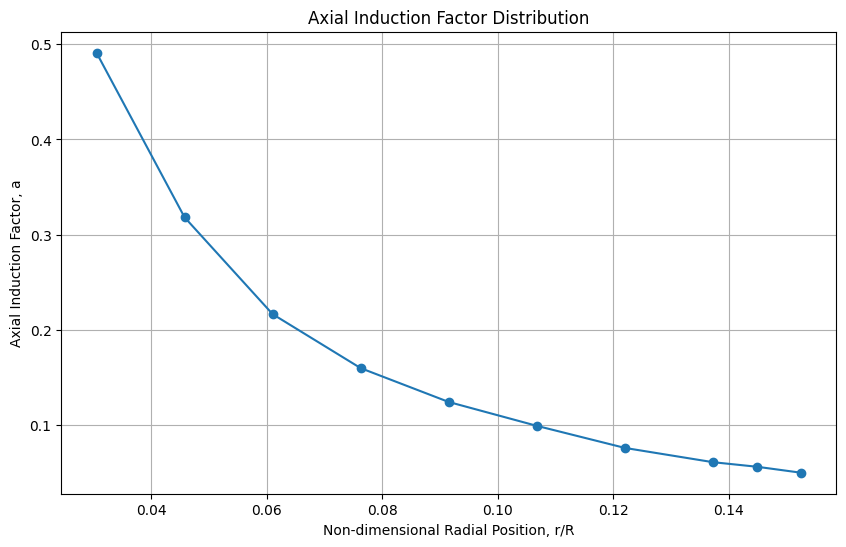

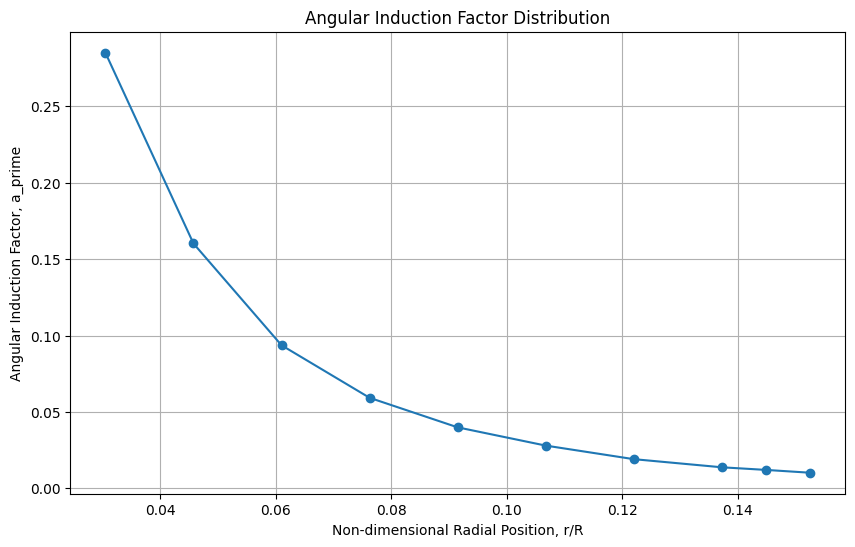

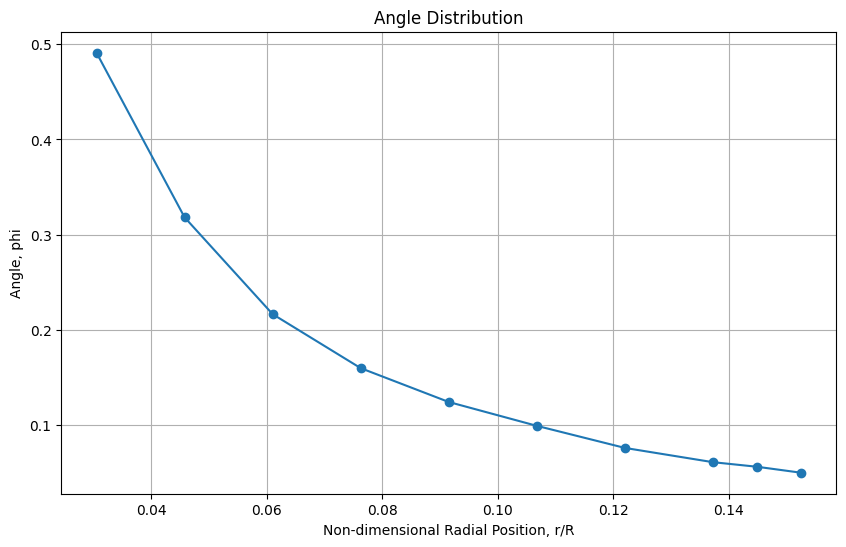

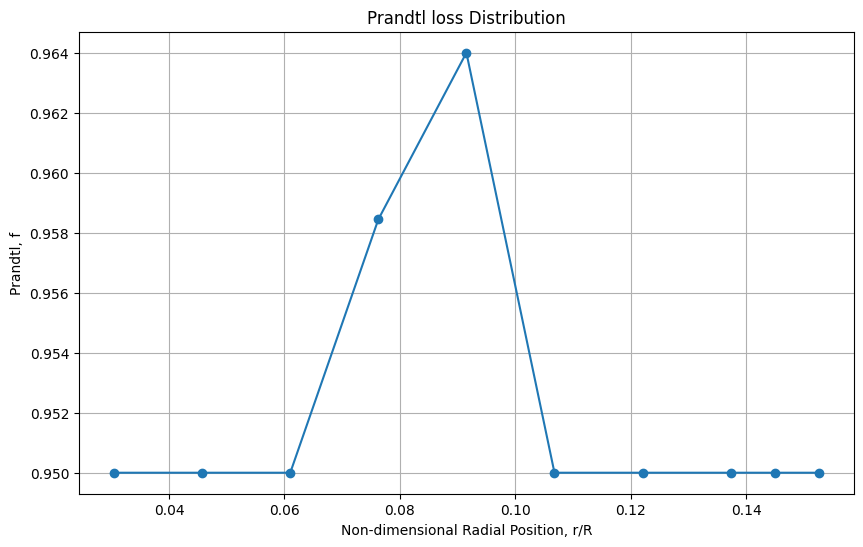

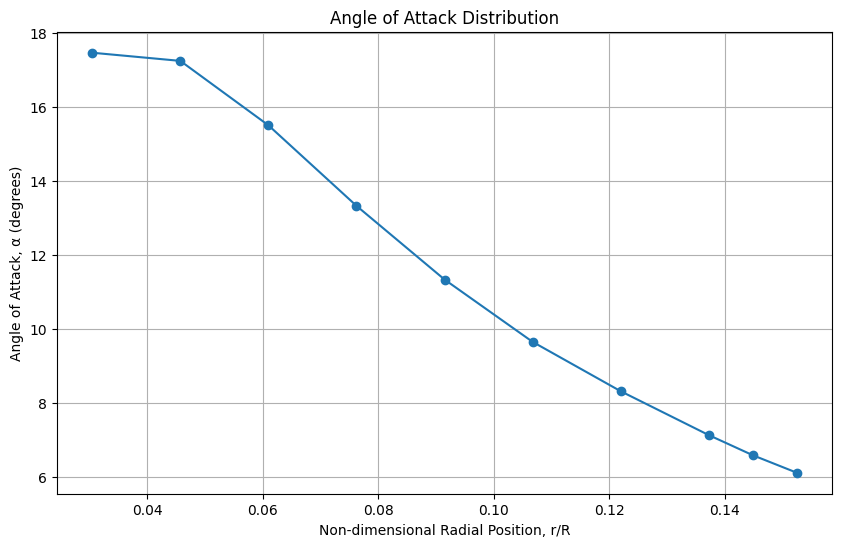

In [53]:
print(f"Total Thrust, T = {T:.5f} N")
print(f"Total Torque, Q = {Q:.5f} Nm")
print(f"Thrust Coefficient, K_T = {K_T:.5f}")
print(f"Torque Coefficient, K_Q = {K_Q:.5f}")
print(f"Advance Coefficient, J = {J:.5f}")
print(f"Propeller Efficiency, η = {eta:.5f}")

# Plot axial induction factor along the blade
plt.figure(figsize=(10, 6))
plt.plot(r, a, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Axial Induction Factor, a')
plt.title('Axial Induction Factor Distribution')
plt.grid(True)
plt.show()

# Plot angular induction factor along the blade
plt.figure(figsize=(10, 6))
plt.plot(r, a_prime, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Angular Induction Factor, a_prime')
plt.title('Angular Induction Factor Distribution')
plt.grid(True)
plt.show()

# Plot phi angle along the blade
plt.figure(figsize=(10, 6))
plt.plot(r, a, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Angle, phi')
plt.title('Angle Distribution')
plt.grid(True)
plt.show()

# Plot phi angle along the blade
plt.figure(figsize=(10, 6))
plt.plot(r, f, marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Prandtl, f')
plt.title('Prandtl loss Distribution')
plt.grid(True)
plt.show()

# Plot angle of attack distribution
plt.figure(figsize=(10, 6))
plt.plot(r, np.degrees(alpha), marker='o')
plt.xlabel('Non-dimensional Radial Position, r/R')
plt.ylabel('Angle of Attack, α (degrees)')
plt.title('Angle of Attack Distribution')
plt.grid(True)
plt.show()